In [ ]:
# ============================================================
# ONE-CELL ALPACA STATIONARY POINT DIAGNOSTIC
# ETF-theme-first + stock-level daily universe
# Finds confirmed maxima/minima and where bot would buy/sell
# ============================================================

# If needed, uncomment this once:
# !pip install alpaca-py

import os
import getpass
import numpy as np
import pandas as pd
from pathlib import Path

from datetime import datetime, timedelta, time
from zoneinfo import ZoneInfo

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from alpaca.data.enums import DataFeed


# ============================================================
# 1. USER SETTINGS
# ============================================================

NY_TZ = ZoneInfo("America/New_York")

# ------------------------------------------------------------
# ETF-theme-first daily universe settings
# ------------------------------------------------------------
# The bot will download bars for:
#   1) candidate stocks it might trade
#   2) group/sector ETFs used only for daily selection
#
# It will choose the top stocks at the start of each trading day
# using strength/momentum, volatility, and gap size.
# It will then wait MARKET_OPEN_BUFFER_MINUTES before allowing buys.

# Sector / market ETFs are used only as confirmation signals.
# They do NOT decide the universe by themselves.
GROUP_ETFS = {
    # Broad market regime
    "S&P 500": "SPY",
    "Nasdaq 100": "QQQ",
    "Russell 2000": "IWM",

    # Core sectors
    "Technology": "XLK",
    "Communication Services": "XLC",
    "Consumer Discretionary": "XLY",
    "Consumer Staples": "XLP",
    "Energy": "XLE",
    "Financials": "XLF",
    "Healthcare": "XLV",
    "Industrials": "XLI",
    "Materials": "XLB",
    "Real Estate": "XLRE",
    "Utilities": "XLU",
}

# ETFs used to choose the current market theme.
# These are intentionally hard-coded. They are not the traded stocks;
# they are only "battlefield"/theme detectors.
POPULAR_ETFS_FOR_UNIVERSE = {
    "S&P 500": "SPY",
    "Nasdaq 100": "QQQ",
    "Technology": "XLK",
    "Semiconductors": "SMH",
    "Energy": "XLE",
    "Financials": "XLF",
    "Healthcare": "XLV",
    "Consumer Discretionary": "XLY",
    "Communication Services": "XLC",
    "Industrials": "XLI",
}

# Approximate mapping from an ETF theme to S&P 500 sectors/sub-industries.
# This avoids needing to download ETF holdings. The ETF chooses the theme;
# the stock-level final_score still chooses the actual stocks.
THEME_TO_ALLOWED_SECTORS = {
    "S&P 500": None,          # broad theme: no sector restriction
    "Russell 2000": None,     # broad/risk-on theme: no sector restriction
    "Nasdaq 100": ["Information Technology", "Communication Services", "Consumer Discretionary"],
    "Technology": ["Information Technology"],
    "Semiconductors": ["Information Technology"],
    "Energy": ["Energy"],
    "Financials": ["Financials"],
    "Healthcare": ["Health Care"],
    "Consumer Discretionary": ["Consumer Discretionary"],
    "Communication Services": ["Communication Services"],
    "Industrials": ["Industrials"],
}

THEME_TO_SUB_INDUSTRY_KEYWORDS = {
    "Semiconductors": ["semiconductor", "semiconductors", "semiconductor equipment"],
}

SECTOR_TO_ETF = {
    "Information Technology": "XLK",
    "Communication Services": "XLC",
    "Consumer Discretionary": "XLY",
    "Consumer Staples": "XLP",
    "Energy": "XLE",
    "Financials": "XLF",
    "Health Care": "XLV",
    "Industrials": "XLI",
    "Materials": "XLB",
    "Real Estate": "XLRE",
    "Utilities": "XLU",
}

# ------------------------------------------------------------
# ETF-theme-first dynamic universe settings
# ------------------------------------------------------------
# New method:
#   1) Fetch S&P 500 constituents dynamically.
#   2) Rank S&P 500 stocks by recent average dollar volume.
#   3) Keep the top 65 as a high-quality liquid stock pool.
#   4) Rank the hard-coded ETF themes by medium-term growth.
#   5) Each day, prioritise stocks related to the strongest ETF theme.
#   6) Inside that theme, use the existing stock-level final_score:
#        - historical stationary-point suitability proxy
#        - daily strength / relative momentum
#        - tradable volatility
#        - market / sector confirmation
#        - gap penalty
#   7) Pick the top 5 for that day.

TOP_SP500_STOCK_COUNT = 65
MAX_STOCKS_PER_DAY = 5
MAX_STOCKS_PER_SECTOR = 5  # ETF-theme-first selection can intentionally concentrate.

# ETF theme ranking. 126 trading days is roughly 6 months.
ETF_GROWTH_LOOKBACK_BARS = 126
ETF_GROWTH_LOOKBACK_CALENDAR_DAYS = 220
MIN_ETF_GROWTH_BARS = 20

# If True, theme-matching stocks are considered first. If fewer than 5 are available,
# the selector fills from the broader top-65 pool.
PRIORITISE_STRONGEST_ETF_THEME = True

# Used to form the top-65 candidate pool before the backtest starts.
LIQUIDITY_LOOKBACK_DAYS = 60
MIN_LIQUIDITY_DAILY_BARS = 10

# Used inside daily scoring.
SUITABILITY_LOOKBACK_DAYS = 8

# Wait after market open before buys are allowed.
# 15 means regular-session signals before 9:45 a.m. New York time are ignored.
MARKET_OPEN_BUFFER_MINUTES = 15

# Final-score weights. These sum to 1 before the gap penalty.
HISTORICAL_SUITABILITY_WEIGHT = 0.60
DAILY_STRENGTH_WEIGHT = 0.20
TRADABLE_VOLATILITY_WEIGHT = 0.10
MARKET_SECTOR_CONFIRMATION_WEIGHT = 0.10

# Gap penalty is subtracted from the final score.
# Keep this moderate: huge gaps are bad, but a tiny/moderate gap can still be useful.
GAP_PENALTY_WEIGHT = 0.20

# Avoid stocks that gap too much relative to their normal daily range.
# Example: 2.0 means the gap is 2.0x recent ATR.
MAX_GAP_VS_ATR = 2.0

# These are populated dynamically in section 8 after the Alpaca client is available.
TICKERS = []
DOWNLOAD_TICKERS = []
SP500_CONSTITUENTS_DF = pd.DataFrame()
TOP_SP500_UNIVERSE_DF = pd.DataFrame()
STOCK_TO_SECTOR = {}
STOCK_TO_SECTOR_ETF = {}
STOCK_TO_SUB_INDUSTRY = {}

# Change this to whatever trading period you want to test.
END_TIME = datetime.now(tz=NY_TZ)
START_TIME = END_TIME - timedelta(weeks=3)

# Alpaca can do custom minute bars.
# Try 3, 5, 10, 15, etc.
BAR_MINUTES = 3
TIMEFRAME = TimeFrame(BAR_MINUTES, TimeFrameUnit.Minute)

# If you are on Alpaca free data, use IEX.
# If you have SIP data access, you can change this to DataFeed.SIP.
DATA_FEED = DataFeed.IEX

# Stationary point settings
SMOOTH_WINDOW = 5
VOL_WINDOW = 20
ATR_WINDOW = 14

# ORDER means how many candles on each side are used to confirm a point.
# Example:
# BAR_MINUTES = 5 and ORDER = 3
# means confirmation delay is 15 minutes.
ORDER = 3

# Reject tiny swings.
# 0.001 = 0.1%
# 0.002 = 0.2%
# Set to 0.0 if you want no swing filter.
MIN_SWING_PCT = 0.001


# ============================================================
# 2. ALPACA API KEYS - ASK AT RUNTIME, DO NOT HARDCODE
# ============================================================

import os
import getpass

ALPACA_API_KEY = os.getenv("ALPACA_API_KEY")
ALPACA_SECRET_KEY = os.getenv("ALPACA_SECRET_KEY")

# If environment variables are not set, ask inside VS Code/Jupyter
if not ALPACA_API_KEY:
    ALPACA_API_KEY = getpass.getpass("Enter your Alpaca API key: ")

if not ALPACA_SECRET_KEY:
    ALPACA_SECRET_KEY = getpass.getpass("Enter your Alpaca secret key: ")

if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
    raise ValueError("Alpaca API key or secret key was not provided.")

stock_client = StockHistoricalDataClient(
    ALPACA_API_KEY,
    ALPACA_SECRET_KEY
)

print("Alpaca data client created successfully.")


# ============================================================
# 3. FEATURE FUNCTIONS
# ============================================================

def compute_atr(df, window=14):
    high = df["High"]
    low = df["Low"]
    close = df["Close"]
    prev_close = close.shift(1)

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    return true_range.rolling(window=window, min_periods=window).mean()


def prepare_features(df):
    df = df.copy()

    df["smooth_price"] = (
        df["Close"]
        .rolling(window=SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW)
        .mean()
    )

    df["first_derivative"] = df["smooth_price"].diff()
    df["second_derivative"] = df["first_derivative"].diff()

    df["returns"] = df["Close"].pct_change()

    df["rolling_volatility"] = (
        df["returns"]
        .rolling(window=VOL_WINDOW, min_periods=VOL_WINDOW)
        .std()
    )

    df["ATR"] = compute_atr(df, window=ATR_WINDOW)
    df["ATR_percent"] = df["ATR"] / df["Close"]

    return df


# ============================================================
# 4. ALPACA DATA FETCH
# ============================================================

def get_alpaca_stock_bars(symbols, start_time, end_time, timeframe, feed=DataFeed.IEX):
    request = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=timeframe,
        start=start_time,
        end=end_time,
        feed=feed
    )

    bars = stock_client.get_stock_bars(request)
    df = bars.df

    if df.empty:
        return pd.DataFrame()

    df = df.reset_index()

    rename_map = {
        "symbol": "ticker",
        "timestamp": "time",
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume",
        "trade_count": "TradeCount",
        "vwap": "VWAP"
    }

    df = df.rename(columns=rename_map)

    # Convert timestamps to New York time for readability
    if df["time"].dt.tz is None:
        df["time"] = df["time"].dt.tz_localize("UTC")

    df["time"] = df["time"].dt.tz_convert(NY_TZ)

    df = df.sort_values(["ticker", "time"]).reset_index(drop=True)

    return df



# ============================================================
# ============================================================
# 4B. DYNAMIC TOP-65 S&P 500 UNIVERSE + DAILY STOCK SELECTION
# ============================================================

def standardize_symbol_for_alpaca(symbol):
    """
    Standardises ticker symbols from public S&P 500 tables.
    Most symbols are unchanged. This function is kept separate so it is easy
    to adjust if your broker/data feed represents special tickers differently.
    """
    return str(symbol).strip()

SP500_CACHE_PATH = Path("sp500_constituents_cache.csv")

SP500_CSV_URL = (
    "https://raw.githubusercontent.com/datasets/"
    "s-and-p-500-companies/main/data/constituents.csv"
)

def fetch_sp500_constituents(refresh=False):
    """
    Gets the S&P 500 constituent list from a simple GitHub CSV source,
    then saves a local cache.

    This avoids pd.read_html(), so it does not need lxml/html5lib/bs4.
    If the online fetch fails but a cache exists, the cache is used.
    """

    # Use cached copy unless we explicitly ask to refresh
    if SP500_CACHE_PATH.exists() and not refresh:
        print(f"Loading S&P 500 constituents from cache: {SP500_CACHE_PATH}")
        constituents = pd.read_csv(SP500_CACHE_PATH)

    else:
        try:
            print("Fetching S&P 500 constituents from GitHub CSV...")
            constituents = pd.read_csv(SP500_CSV_URL)

            if "Symbol" not in constituents.columns:
                raise ValueError(
                    f"Expected a 'Symbol' column, but got: {constituents.columns.tolist()}"
                )

            constituents.to_csv(SP500_CACHE_PATH, index=False)
            print(f"Saved S&P 500 constituents to cache: {SP500_CACHE_PATH}")

        except Exception as exc:
            print("Online S&P 500 fetch failed:", repr(exc))

            if SP500_CACHE_PATH.exists():
                print(f"Falling back to cached S&P 500 list: {SP500_CACHE_PATH}")
                constituents = pd.read_csv(SP500_CACHE_PATH)
            else:
                raise RuntimeError(
                    "Could not fetch the S&P 500 constituent list and no cache exists. "
                    "Check internet connection, or manually create sp500_constituents_cache.csv."
                ) from exc

    # Standardise columns so the rest of the notebook still works
    rename_map = {
        "Symbol": "ticker",
        "Security": "company",
        "Name": "company",
        "GICS Sector": "sector",
        "Sector": "sector",
        "GICS Sub-Industry": "sub_industry",
        "Sub-Industry": "sub_industry",
    }

    constituents = constituents.rename(
        columns={old: new for old, new in rename_map.items() if old in constituents.columns}
    )

    required_cols = {"ticker", "company", "sector"}
    missing = required_cols - set(constituents.columns)

    if missing:
        raise RuntimeError(
            f"S&P 500 CSV format issue. Missing columns after rename: {missing}. "
            f"Available columns: {constituents.columns.tolist()}"
        )

    if "sub_industry" not in constituents.columns:
        constituents["sub_industry"] = ""

    constituents["ticker"] = (
    constituents["ticker"]
    .astype(str)
    .str.strip()
     )

    constituents["sector_etf"] = constituents["sector"].map(SECTOR_TO_ETF)
    constituents = constituents[constituents["sector_etf"].notna()].copy()

    return (
        constituents[["ticker", "company", "sector", "sector_etf", "sub_industry"]]
        .drop_duplicates("ticker")
        .reset_index(drop=True)
    )

def build_top_sp500_liquidity_universe(sp500_constituents, daily_bars_df, top_n=65):
    """
    Uses recent daily bars to select the top-N S&P 500 stocks by average dollar volume.

    This is the dynamic Tier-1 candidate universe:
        S&P 500 -> top 65 by liquidity / attention.
    """
    if daily_bars_df.empty:
        raise ValueError("daily_bars_df is empty; cannot build top S&P 500 liquidity universe.")

    df = daily_bars_df.copy()
    df["date"] = df["time"].dt.date
    df = df[df["ticker"].isin(sp500_constituents["ticker"])].copy()

    if df.empty:
        raise ValueError("No S&P 500 symbols returned daily bars from Alpaca.")

    df["dollar_volume"] = df["Close"] * df["Volume"]

    liquidity = (
        df.groupby("ticker")
        .agg(
            avg_close=("Close", "mean"),
            avg_volume=("Volume", "mean"),
            avg_dollar_volume=("dollar_volume", "mean"),
            valid_daily_bars=("date", "nunique"),
        )
        .reset_index()
    )

    liquidity = liquidity[liquidity["valid_daily_bars"] >= MIN_LIQUIDITY_DAILY_BARS].copy()

    universe = (
        liquidity
        .merge(sp500_constituents, on="ticker", how="left")
        .sort_values("avg_dollar_volume", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    if universe.empty:
        raise ValueError("Top S&P 500 liquidity universe is empty after filtering.")

    return universe


def build_daily_ohlcv(intraday_df):
    """
    Converts intraday bars into one OHLCV row per ticker per date.
    Used to calculate previous close, previous volume, and ATR-like volatility.
    """
    df = intraday_df.copy()
    df["date"] = df["time"].dt.date

    daily = (
        df.groupby(["ticker", "date"])
        .agg(
            Open=("Open", "first"),
            High=("High", "max"),
            Low=("Low", "min"),
            Close=("Close", "last"),
            Volume=("Volume", "sum")
        )
        .reset_index()
        .sort_values(["ticker", "date"])
    )

    daily["prev_close"] = daily.groupby("ticker")["Close"].shift(1)
    daily["prev_volume"] = daily.groupby("ticker")["Volume"].shift(1)
    daily["prev_dollar_volume"] = daily["prev_close"] * daily["prev_volume"]

    high = daily["High"]
    low = daily["Low"]
    prev_close = daily["prev_close"]

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    daily["true_range"] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    daily["ATR_daily"] = (
        daily.groupby("ticker")["true_range"]
        .transform(lambda s: s.rolling(ATR_WINDOW, min_periods=3).mean())
        .shift(1)
    )
    daily["ATR_percent_daily"] = daily["ATR_daily"] / daily["prev_close"]

    daily["daily_range_pct"] = (daily["High"] - daily["Low"]) / daily["Open"].replace(0, np.nan)

    return daily


def first_bar_features(intraday_df):
    """
    Gets the first regular-session bar for each ticker/date.
    In this notebook, this first bar is used as the backtest approximation
    of the at-open / overnight signal.
    """
    df = intraday_df.copy()
    df["date"] = df["time"].dt.date

    first_rows = (
        df.sort_values(["ticker", "time"])
        .groupby(["ticker", "date"])
        .first()
        .reset_index()
    )

    return first_rows[["ticker", "date", "time", "Open", "Close", "Volume"]].rename(
        columns={
            "time": "first_bar_time",
            "Open": "day_open",
            "Close": "first_bar_close",
            "Volume": "first_bar_volume",
        }
    )


def build_intraday_quality_features(intraday_df):
    """
    Builds per-ticker, per-day quality features from intraday bars.

    These are historical suitability proxies for the stationary-point bot:
        - enough intraday range
        - enough clean turning-point opportunity
        - not too much random noisy movement
        - enough bars/volume
    """
    rows = []

    for (ticker, current_date), day_df in intraday_df.groupby(["ticker", intraday_df["time"].dt.date]):
        day_df = day_df.sort_values("time").copy()

        if len(day_df) < max(6, SMOOTH_WINDOW + 2):
            continue

        close = day_df["Close"].astype(float)
        smooth = close.rolling(SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW).mean()

        # Simple approximate turning-point count for suitability only.
        approx_min = (smooth.shift(1) > smooth) & (smooth.shift(-1) > smooth)
        approx_max = (smooth.shift(1) < smooth) & (smooth.shift(-1) < smooth)
        approx_extrema_count = int((approx_min | approx_max).sum())

        open_price = float(day_df["Open"].iloc[0])
        close_price = float(day_df["Close"].iloc[-1])
        high_price = float(day_df["High"].max())
        low_price = float(day_df["Low"].min())

        intraday_range_pct = (high_price - low_price) / open_price if open_price else np.nan
        abs_bar_move_sum = close.pct_change().abs().sum()
        abs_open_to_close_move = abs(close_price / open_price - 1.0) if open_price else np.nan

        # Larger values mean more random back-and-forth relative to net movement.
        # Some back-and-forth is good for stationary points; extreme values are noisy.
        choppiness = abs_bar_move_sum / (abs_open_to_close_move + 0.001)

        rows.append({
            "ticker": ticker,
            "date": current_date,
            "intraday_range_pct": intraday_range_pct,
            "approx_extrema_count": approx_extrema_count,
            "choppiness": choppiness,
            "valid_intraday_bars": len(day_df),
        })

    return pd.DataFrame(rows)


def percentile_rank(series):
    """
    Stable percentile rank helper.
    Higher values get higher ranks.
    """
    return series.rank(pct=True).fillna(0.0)


def _safe_minmax(series):
    """
    Simple 0-1 scaling for one cross-section. Returns 0.5 if all values are equal.
    """
    s = series.astype(float).replace([np.inf, -np.inf], np.nan)
    mn = s.min()
    mx = s.max()

    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(0.5, index=series.index)

    return (s - mn) / (mx - mn)


def stock_matches_etf_theme(row, theme_name):
    """
    Returns True if a stock belongs to the chosen ETF theme.

    This is a practical approximation using S&P 500 sector/sub-industry metadata.
    It avoids downloading ETF holdings while still letting the strongest ETF theme
    focus the universe selection.
    """
    allowed_sectors = THEME_TO_ALLOWED_SECTORS.get(theme_name)

    # Broad themes, such as SPY, do not restrict by sector.
    if allowed_sectors is None:
        return True

    sector = row.get("sector", None)
    sub_industry = str(row.get("sub_industry", "")).lower()

    sector_match = sector in allowed_sectors
    keyword_match = any(
        keyword.lower() in sub_industry
        for keyword in THEME_TO_SUB_INDUSTRY_KEYWORDS.get(theme_name, [])
    )

    # For semiconductor theme, require sub-industry evidence if available.
    if theme_name == "Semiconductors":
        return keyword_match or (sector_match and "semiconductor" in sub_industry)

    return bool(sector_match or keyword_match)


def build_etf_theme_growth_scores(etf_daily_bars_df, backtest_dates):
    """
    Ranks the hard-coded ETF themes by medium-term growth for each backtest day.

    Uses only ETF daily closes strictly before each trading day, so there is no
    same-day lookahead. The strongest ETF becomes the daily market theme.
    """
    if etf_daily_bars_df is None or etf_daily_bars_df.empty:
        return pd.DataFrame()

    df = etf_daily_bars_df.copy()
    df["date"] = df["time"].dt.date
    df = df[df["ticker"].isin(POPULAR_ETFS_FOR_UNIVERSE.values())].copy()
    df = df.sort_values(["ticker", "date"])

    etf_to_theme = {etf: theme for theme, etf in POPULAR_ETFS_FOR_UNIVERSE.items()}
    rows = []

    for current_date in sorted(backtest_dates):
        for etf in POPULAR_ETFS_FOR_UNIVERSE.values():
            hist = df[(df["ticker"] == etf) & (df["date"] < current_date)].copy()
            hist = hist.dropna(subset=["Close"]).sort_values("date")

            if len(hist) < MIN_ETF_GROWTH_BARS:
                continue

            end_close = float(hist["Close"].iloc[-1])

            if len(hist) > ETF_GROWTH_LOOKBACK_BARS:
                start_close = float(hist["Close"].iloc[-ETF_GROWTH_LOOKBACK_BARS - 1])
                bars_used = ETF_GROWTH_LOOKBACK_BARS
            else:
                start_close = float(hist["Close"].iloc[0])
                bars_used = len(hist) - 1

            if start_close <= 0 or not np.isfinite(start_close):
                continue

            growth_return = (end_close / start_close) - 1.0

            rows.append({
                "date": current_date,
                "theme": etf_to_theme.get(etf, etf),
                "theme_etf": etf,
                "etf_growth_return": growth_return,
                "etf_growth_bars_used": bars_used,
                "etf_start_close": start_close,
                "etf_end_close": end_close,
            })

    scores = pd.DataFrame(rows)

    if scores.empty:
        return scores

    scores = scores.sort_values(["date", "etf_growth_return"], ascending=[True, False])
    scores["etf_growth_rank"] = scores.groupby("date")["etf_growth_return"].rank(
        ascending=False,
        method="first"
    )
    scores["is_selected_theme"] = scores["etf_growth_rank"] == 1

    return scores.reset_index(drop=True)


def build_daily_universe_selection(raw_bars_df, etf_theme_scores_df=None):
    """
    Picks a fresh top-5 stock universe for each trading day.

    ETF-theme-first selection method:
        1) Candidate pool is the dynamic top-65 S&P 500 liquidity universe.
        2) ETF themes are ranked by medium-term growth.
        3) Stocks matching the strongest ETF theme are prioritised.
        4) Inside the prioritised theme, each stock gets the existing final_score.
        5) The top 5 are selected for that day.

    Important:
        With IEX data, this uses the first available regular-session bar
        as the opening signal. If you later use reliable pre-market data,
        swap the first-bar signal for true pre-market features.
    """
    bars = raw_bars_df.copy()

    if bars.empty:
        raise ValueError("raw_bars_df is empty; cannot build daily universe.")

    if not TICKERS:
        raise ValueError("TICKERS is empty. Build the dynamic top-65 S&P 500 universe first.")

    daily = build_daily_ohlcv(bars)
    first = first_bar_features(bars)
    quality = build_intraday_quality_features(bars)

    features = first.merge(
        daily[[
            "ticker", "date", "prev_close", "prev_volume", "prev_dollar_volume",
            "ATR_daily", "ATR_percent_daily", "daily_range_pct"
        ]],
        on=["ticker", "date"],
        how="left"
    )

    if not quality.empty:
        features = features.merge(quality, on=["ticker", "date"], how="left")
    else:
        features["intraday_range_pct"] = np.nan
        features["approx_extrema_count"] = np.nan
        features["choppiness"] = np.nan
        features["valid_intraday_bars"] = np.nan

    features["open_momentum"] = (
        (features["day_open"] - features["prev_close"]) / features["prev_close"]
    )
    features["gap_pct"] = features["open_momentum"]
    features["gap_vs_atr"] = (
        (features["day_open"] - features["prev_close"]).abs() / features["ATR_daily"]
    )

    features["volatility_score_raw"] = features["ATR_percent_daily"].replace([np.inf, -np.inf], np.nan)
    features["liquidity_score_raw"] = np.log1p(features["prev_dollar_volume"].clip(lower=0))

    # ------------------------------------------------------------------
    # Market / sector ETF confirmation features
    # ------------------------------------------------------------------
    etf_to_group = {etf: group for group, etf in GROUP_ETFS.items()}

    group_features = features[features["ticker"].isin(GROUP_ETFS.values())].copy()
    group_features["group"] = group_features["ticker"].map(etf_to_group)

    group_feature_rows = []

    for current_date, day_group_df in group_features.groupby("date"):
        day_group_df = day_group_df.copy()
        day_group_df["momentum_rank"] = percentile_rank(day_group_df["open_momentum"])
        day_group_df["volatility_rank"] = percentile_rank(day_group_df["volatility_score_raw"])
        day_group_df["gap_penalty_rank"] = percentile_rank(day_group_df["gap_pct"].abs())

        day_group_df["group_score"] = (
            0.65 * day_group_df["momentum_rank"]
            + 0.25 * day_group_df["volatility_rank"]
            - 0.10 * day_group_df["gap_penalty_rank"]
        )

        group_feature_rows.append(day_group_df.sort_values("group_score", ascending=False))

    group_scores_df = (
        pd.concat(group_feature_rows, ignore_index=True)
        if group_feature_rows
        else pd.DataFrame()
    )

    # Maps used for daily confirmation.
    sp500_momentum_by_date = {}
    qqq_momentum_by_date = {}
    sector_momentum_by_date_and_etf = {}

    if not group_scores_df.empty:
        spy_rows = group_scores_df[group_scores_df["ticker"] == "SPY"]
        qqq_rows = group_scores_df[group_scores_df["ticker"] == "QQQ"]

        sp500_momentum_by_date = dict(zip(spy_rows["date"], spy_rows["open_momentum"]))
        qqq_momentum_by_date = dict(zip(qqq_rows["date"], qqq_rows["open_momentum"]))

        for _, row in group_scores_df.iterrows():
            sector_momentum_by_date_and_etf[(row["date"], row["ticker"])] = row["open_momentum"]

    # ------------------------------------------------------------------
    # Strongest ETF theme per day.
    # ------------------------------------------------------------------
    selected_theme_by_date = {}

    if etf_theme_scores_df is not None and not etf_theme_scores_df.empty:
        selected_theme_rows = etf_theme_scores_df[etf_theme_scores_df["is_selected_theme"]].copy()
        for _, row in selected_theme_rows.iterrows():
            selected_theme_by_date[row["date"]] = {
                "selected_theme": row["theme"],
                "selected_theme_etf": row["theme_etf"],
                "selected_theme_growth": row["etf_growth_return"],
                "selected_theme_growth_bars_used": row["etf_growth_bars_used"],
            }

    # ------------------------------------------------------------------
    # Historical suitability features.
    # All suitability columns are shifted by 1 day, so each day only uses
    # earlier information.
    # ------------------------------------------------------------------
    stock_features = features[features["ticker"].isin(TICKERS)].copy()
    stock_features = stock_features.sort_values(["ticker", "date"]).reset_index(drop=True)

    rolling_cols = {
        "prev_dollar_volume": "hist_dollar_volume",
        "ATR_percent_daily": "hist_atr_pct",
        "daily_range_pct": "hist_range_pct",
        "approx_extrema_count": "hist_extrema_count",
        "choppiness": "hist_choppiness",
        "valid_intraday_bars": "hist_valid_bars",
    }

    for source_col, target_col in rolling_cols.items():
        stock_features[target_col] = (
            stock_features.groupby("ticker")[source_col]
            .transform(lambda s: s.shift(1).rolling(SUITABILITY_LOOKBACK_DAYS, min_periods=2).mean())
        )

    stock_features["sector"] = stock_features["ticker"].map(STOCK_TO_SECTOR)
    stock_features["sector_etf"] = stock_features["ticker"].map(STOCK_TO_SECTOR_ETF)
    stock_features["sub_industry"] = stock_features["ticker"].map(STOCK_TO_SUB_INDUSTRY)

    selected_rows = []
    scoring_rows = []

    for current_date, day_stock_df in stock_features.groupby("date"):
        day_stock_df = day_stock_df.copy()

        if day_stock_df.empty:
            continue

        theme_info = selected_theme_by_date.get(current_date, {
            "selected_theme": "S&P 500",
            "selected_theme_etf": "SPY",
            "selected_theme_growth": np.nan,
            "selected_theme_growth_bars_used": np.nan,
        })

        selected_theme = theme_info["selected_theme"]
        day_stock_df["selected_theme"] = selected_theme
        day_stock_df["selected_theme_etf"] = theme_info["selected_theme_etf"]
        day_stock_df["selected_theme_growth"] = theme_info["selected_theme_growth"]
        day_stock_df["selected_theme_growth_bars_used"] = theme_info["selected_theme_growth_bars_used"]
        day_stock_df["theme_match"] = day_stock_df.apply(
            lambda row: stock_matches_etf_theme(row, selected_theme),
            axis=1
        )

        # Daily relative strength.
        spy_mom = sp500_momentum_by_date.get(current_date, 0.0)
        qqq_mom = qqq_momentum_by_date.get(current_date, 0.0)

        day_stock_df["spy_open_momentum"] = spy_mom
        day_stock_df["qqq_open_momentum"] = qqq_mom
        day_stock_df["sector_open_momentum"] = day_stock_df["sector_etf"].apply(
            lambda etf: sector_momentum_by_date_and_etf.get((current_date, etf), 0.0)
        )

        day_stock_df["relative_strength_vs_spy"] = day_stock_df["open_momentum"] - day_stock_df["spy_open_momentum"]
        day_stock_df["relative_strength_vs_qqq"] = day_stock_df["open_momentum"] - day_stock_df["qqq_open_momentum"]
        day_stock_df["relative_strength_vs_sector"] = day_stock_df["open_momentum"] - day_stock_df["sector_open_momentum"]

        # Do not select deeply weak stocks. Slightly negative stocks can still rank
        # if they are strong relative to SPY/sector.
        day_stock_df = day_stock_df[
            (day_stock_df["open_momentum"] > -0.0075)
            & (day_stock_df["relative_strength_vs_sector"] > -0.0075)
        ].copy()

        # Avoid extremely stretched gaps unless ATR is unavailable.
        day_stock_df = day_stock_df[
            (day_stock_df["gap_vs_atr"].isna())
            | (day_stock_df["gap_vs_atr"] <= MAX_GAP_VS_ATR)
        ].copy()

        if day_stock_df.empty:
            continue

        # Historical suitability score components.
        day_stock_df["hist_liquidity_rank"] = percentile_rank(day_stock_df["hist_dollar_volume"])
        day_stock_df["hist_range_rank"] = percentile_rank(day_stock_df["hist_range_pct"])
        day_stock_df["hist_volatility_rank"] = percentile_rank(day_stock_df["hist_atr_pct"])
        day_stock_df["hist_extrema_rank"] = percentile_rank(day_stock_df["hist_extrema_count"])

        # Lower choppiness is cleaner, but completely smooth/trend-only stocks may have fewer extrema.
        # This is a simple first version: prefer less choppy names, but the extrema/range terms
        # prevent the score from rewarding dead-flat stocks too much.
        day_stock_df["hist_cleanliness_rank"] = percentile_rank(-day_stock_df["hist_choppiness"])

        day_stock_df["historical_suitability_score"] = (
            0.30 * day_stock_df["hist_liquidity_rank"]
            + 0.20 * day_stock_df["hist_range_rank"]
            + 0.20 * day_stock_df["hist_volatility_rank"]
            + 0.20 * day_stock_df["hist_extrema_rank"]
            + 0.10 * day_stock_df["hist_cleanliness_rank"]
        )

        # Fallback for the first few days where not enough history exists.
        day_stock_df["historical_suitability_score"] = day_stock_df["historical_suitability_score"].fillna(
            percentile_rank(day_stock_df["liquidity_score_raw"])
        )

        # Daily opportunity score.
        day_stock_df["daily_strength_raw"] = (
            0.40 * day_stock_df["open_momentum"]
            + 0.25 * day_stock_df["relative_strength_vs_spy"]
            + 0.20 * day_stock_df["relative_strength_vs_sector"]
            + 0.15 * day_stock_df["relative_strength_vs_qqq"]
        )

        day_stock_df["daily_strength_score"] = percentile_rank(day_stock_df["daily_strength_raw"])

        # Tradable volatility: enough movement to matter, but still liquid/large-cap.
        day_stock_df["tradable_volatility_score"] = percentile_rank(day_stock_df["volatility_score_raw"])

        # Market and sector confirmation.
        # Positive SPY/sector momentum is better; relative strength also helps.
        day_stock_df["market_sector_confirmation_raw"] = (
            0.40 * day_stock_df["spy_open_momentum"]
            + 0.25 * day_stock_df["qqq_open_momentum"]
            + 0.25 * day_stock_df["sector_open_momentum"]
            + 0.10 * day_stock_df["relative_strength_vs_sector"]
        )
        day_stock_df["market_sector_confirmation_score"] = percentile_rank(day_stock_df["market_sector_confirmation_raw"])

        # Gap penalty: prefer smaller/moderate gaps.
        day_stock_df["gap_penalty_score"] = percentile_rank(day_stock_df["gap_pct"].abs())

        day_stock_df["final_score"] = (
            HISTORICAL_SUITABILITY_WEIGHT * day_stock_df["historical_suitability_score"]
            + DAILY_STRENGTH_WEIGHT * day_stock_df["daily_strength_score"]
            + TRADABLE_VOLATILITY_WEIGHT * day_stock_df["tradable_volatility_score"]
            + MARKET_SECTOR_CONFIRMATION_WEIGHT * day_stock_df["market_sector_confirmation_score"]
            - GAP_PENALTY_WEIGHT * day_stock_df["gap_penalty_score"]
        )

        # Keep the old name too so the backtest/display code remains compatible.
        day_stock_df["stock_score"] = day_stock_df["final_score"]

        day_stock_df = day_stock_df.sort_values("final_score", ascending=False)
        scoring_rows.append(day_stock_df)

        # ETF-theme-first ordering:
        #   - theme-matching stocks are considered first
        #   - if fewer than 5 good theme names exist, the selector fills from the broader top-65 pool
        if PRIORITISE_STRONGEST_ETF_THEME:
            theme_pool = day_stock_df[day_stock_df["theme_match"]].sort_values("final_score", ascending=False)
            non_theme_pool = day_stock_df[~day_stock_df["theme_match"]].sort_values("final_score", ascending=False)
            candidate_order_df = pd.concat([theme_pool, non_theme_pool], ignore_index=True)
        else:
            candidate_order_df = day_stock_df

        selected_for_day = []
        sector_counts = {}

        for _, row in candidate_order_df.iterrows():
            sector = row.get("sector", "Unknown")

            if sector_counts.get(sector, 0) >= MAX_STOCKS_PER_SECTOR:
                continue

            selected_for_day.append(row)
            sector_counts[sector] = sector_counts.get(sector, 0) + 1

            if len(selected_for_day) >= MAX_STOCKS_PER_DAY:
                break

        # If the sector cap leaves fewer than 5 stocks, fill remaining spots
        # with the next best names regardless of sector.
        if len(selected_for_day) < MAX_STOCKS_PER_DAY:
            selected_tickers = {row["ticker"] for row in selected_for_day}

            for _, row in candidate_order_df.iterrows():
                if row["ticker"] in selected_tickers:
                    continue

                selected_for_day.append(row)
                selected_tickers.add(row["ticker"])

                if len(selected_for_day) >= MAX_STOCKS_PER_DAY:
                    break

        for row in selected_for_day:
            selected_rows.append(row)

    daily_universe_df = (
        pd.DataFrame(selected_rows)
        if selected_rows
        else pd.DataFrame()
    )

    all_stock_scores_df = (
        pd.concat(scoring_rows, ignore_index=True)
        if scoring_rows
        else pd.DataFrame()
    )

    if not daily_universe_df.empty:
        daily_universe_df = daily_universe_df.sort_values(["date", "final_score"], ascending=[True, False])
        daily_universe_df = daily_universe_df.reset_index(drop=True)

    daily_selected_by_date = {}

    if not daily_universe_df.empty:
        for current_date, day_df in daily_universe_df.groupby("date"):
            daily_selected_by_date[current_date] = day_df["ticker"].tolist()

    return daily_universe_df, daily_selected_by_date, group_scores_df, all_stock_scores_df


def get_market_open_buffer_time(current_date):
    """
    Returns the earliest time at which buys are allowed for a date.
    """
    market_open = datetime.combine(current_date, time(9, 30), tzinfo=NY_TZ)
    return market_open + timedelta(minutes=MARKET_OPEN_BUFFER_MINUTES)


# ============================================================
# 5. CANDIDATE EXTREMA DETECTION
# ============================================================

def detect_candidate_extrema(df, order=3, price_col="smooth_price"):
    """
    Detects candidate local minima/maxima.

    This does NOT force alternation.
    It only finds points that independently look like real extrema.

    A candidate minimum needs:
        - price falling into the point
        - point is lowest nearby
        - price rises after

    A candidate maximum needs:
        - price rising into the point
        - point is highest nearby
        - price falls after
    """

    candidates = []

    for i in range(order, len(df) - order):
        current_price = df[price_col].iloc[i]

        if pd.isna(current_price):
            continue

        window = df[price_col].iloc[i - order : i + order + 1]

        if window.isna().any():
            continue

        left_price = df[price_col].iloc[i - order]
        right_price = df[price_col].iloc[i + order]

        was_falling_before = current_price < left_price
        rises_after = right_price > current_price

        was_rising_before = current_price > left_price
        falls_after = right_price < current_price

        is_lowest_nearby = current_price == window.min()
        is_highest_nearby = current_price == window.max()

        if is_lowest_nearby and was_falling_before and rises_after:
            candidates.append({
                "idx": i,
                "extremum_time": df.index[i],
                "stationary_type": "local_minimum",
                "extremum_price": df["Close"].iloc[i],
                "smooth_extremum_price": df["smooth_price"].iloc[i],
            })

        elif is_highest_nearby and was_rising_before and falls_after:
            candidates.append({
                "idx": i,
                "extremum_time": df.index[i],
                "stationary_type": "local_maximum",
                "extremum_price": df["Close"].iloc[i],
                "smooth_extremum_price": df["smooth_price"].iloc[i],
            })

    return pd.DataFrame(candidates)


# ============================================================
# 6. VALIDATE EXTREMA USING YOUR CORRECTED RULE
# ============================================================

def validate_extrema_sequence(candidates_df, min_swing_pct=0.001):
    """
    Validation rule:

    Candidate minimum:
        confirm only if its price is below the previous confirmed maximum.

    Candidate maximum:
        confirm only if its price is above the previous confirmed minimum.

    This does not force alternation.
    It only validates or rejects already-detected candidate extrema.

    Same-type candidates:
        - repeated maxima: keep the higher one
        - repeated minima: keep the lower one
    """

    if candidates_df.empty:
        return candidates_df.copy()

    candidates_df = candidates_df.sort_values("extremum_time").reset_index(drop=True)

    confirmed = []

    for _, row in candidates_df.iterrows():
        curr = row.to_dict()
        curr_type = curr["stationary_type"]
        curr_price = curr["extremum_price"]

        # First candidate becomes initial reference.
        if len(confirmed) == 0:
            curr["validation_status"] = "confirmed_initial_reference"
            curr["swing_from_previous_pct"] = np.nan
            confirmed.append(curr)
            continue

        last = confirmed[-1]
        last_type = last["stationary_type"]
        last_price = last["extremum_price"]

        # Same-type candidate: keep the more extreme one.
        if curr_type == last_type:
            if curr_type == "local_maximum" and curr_price > last_price:
                curr["validation_status"] = "confirmed_replaced_lower_maximum"
                curr["swing_from_previous_pct"] = np.nan
                confirmed[-1] = curr

            elif curr_type == "local_minimum" and curr_price < last_price:
                curr["validation_status"] = "confirmed_replaced_higher_minimum"
                curr["swing_from_previous_pct"] = np.nan
                confirmed[-1] = curr

            continue

        # Candidate minimum after previous confirmed maximum.
        # It must be lower than the previous max.
        if curr_type == "local_minimum" and last_type == "local_maximum":
            swing_pct = (last_price - curr_price) / last_price

            if curr_price < last_price and swing_pct >= min_swing_pct:
                curr["validation_status"] = "confirmed_min_below_previous_max"
                curr["swing_from_previous_pct"] = swing_pct
                confirmed.append(curr)

        # Candidate maximum after previous confirmed minimum.
        # It must be higher than the previous min.
        elif curr_type == "local_maximum" and last_type == "local_minimum":
            swing_pct = (curr_price - last_price) / last_price

            if curr_price > last_price and swing_pct >= min_swing_pct:
                curr["validation_status"] = "confirmed_max_above_previous_min"
                curr["swing_from_previous_pct"] = swing_pct
                confirmed.append(curr)

    return pd.DataFrame(confirmed)


# ============================================================
# 7. BUILD FINAL SIGNAL TABLE
# ============================================================

def build_signal_table(df, ticker, confirmed_df, order=3):
    """
    Builds the final diagnostic table.

    extremum_time:
        when the actual turning point happened.

    confirmation_time:
        when the bot could realistically know the point was confirmed.

    bot_action:
        local_minimum -> BUY / REINVEST CHECK
        local_maximum -> PROFIT-SELL CHECK
    """

    if confirmed_df.empty:
        return pd.DataFrame()

    rows = []

    for _, point in confirmed_df.iterrows():
        i = int(point["idx"])
        confirmation_i = i + order

        if confirmation_i >= len(df):
            continue

        stationary_type = point["stationary_type"]

        if stationary_type == "local_minimum":
            bot_action = "BUY / REINVEST CHECK"
        elif stationary_type == "local_maximum":
            bot_action = "PROFIT-SELL CHECK"
        else:
            bot_action = "NO ACTION"

        extremum_row = df.iloc[i]
        confirmation_row = df.iloc[confirmation_i]

        rows.append({
            "ticker": ticker,
            "stationary_type": stationary_type,
            "bot_action": bot_action,

            "extremum_time": df.index[i],
            "confirmation_time": df.index[confirmation_i],

            "extremum_price": extremum_row["Close"],
            "confirmation_price": confirmation_row["Close"],

            "open": extremum_row["Open"],
            "high": extremum_row["High"],
            "low": extremum_row["Low"],
            "close": extremum_row["Close"],
            "volume": extremum_row["Volume"],

            "smooth_price": extremum_row["smooth_price"],
            "first_derivative": extremum_row["first_derivative"],
            "second_derivative": extremum_row["second_derivative"],

            "rolling_volatility": extremum_row["rolling_volatility"],
            "ATR": extremum_row["ATR"],
            "ATR_percent": extremum_row["ATR_percent"],

            "swing_from_previous_pct": point.get("swing_from_previous_pct", np.nan),
            "validation_status": point.get("validation_status", "")
        })

    return pd.DataFrame(rows)


# ============================================================
# 8. RUN FULL SCAN
# ============================================================

print("=" * 100)
print("Building ETF-theme-first S&P 500 stock universe...")
print("=" * 100)

SP500_CONSTITUENTS_DF = fetch_sp500_constituents()

liquidity_start_time = START_TIME - timedelta(days=LIQUIDITY_LOOKBACK_DAYS)
etf_growth_start_time = START_TIME - timedelta(days=ETF_GROWTH_LOOKBACK_CALENDAR_DAYS)

etf_growth_daily_bars_df = get_alpaca_stock_bars(
    symbols=list(POPULAR_ETFS_FOR_UNIVERSE.values()),
    start_time=etf_growth_start_time,
    end_time=END_TIME,
    timeframe=TimeFrame.Day,
    feed=DATA_FEED
)

sp500_daily_bars_df = get_alpaca_stock_bars(
    symbols=SP500_CONSTITUENTS_DF["ticker"].tolist(),
    start_time=liquidity_start_time,
    end_time=START_TIME,
    timeframe=TimeFrame.Day,
    feed=DATA_FEED
)

TOP_SP500_UNIVERSE_DF = build_top_sp500_liquidity_universe(
    sp500_constituents=SP500_CONSTITUENTS_DF,
    daily_bars_df=sp500_daily_bars_df,
    top_n=TOP_SP500_STOCK_COUNT
)

TICKERS = TOP_SP500_UNIVERSE_DF["ticker"].tolist()
STOCK_TO_SECTOR = dict(zip(TOP_SP500_UNIVERSE_DF["ticker"], TOP_SP500_UNIVERSE_DF["sector"]))
STOCK_TO_SECTOR_ETF = dict(zip(TOP_SP500_UNIVERSE_DF["ticker"], TOP_SP500_UNIVERSE_DF["sector_etf"]))
STOCK_TO_SUB_INDUSTRY = dict(zip(TOP_SP500_UNIVERSE_DF["ticker"], TOP_SP500_UNIVERSE_DF["sub_industry"]))

DOWNLOAD_TICKERS = sorted(set(TICKERS) | set(GROUP_ETFS.values()) | set(POPULAR_ETFS_FOR_UNIVERSE.values()))

print(f"Fetched {len(SP500_CONSTITUENTS_DF)} S&P 500 constituents.")
print(f"Selected top {len(TICKERS)} stocks by recent average dollar volume.")
display_cols = ["ticker", "company", "sector", "avg_dollar_volume", "avg_volume", "valid_daily_bars"]
display_cols = [c for c in display_cols if c in TOP_SP500_UNIVERSE_DF.columns]
display(TOP_SP500_UNIVERSE_DF[display_cols].head(65).round(2))
print("\n")

print("=" * 100)
print("Downloading Alpaca minute bars for top-65 universe + market/sector/theme ETFs...")
print("=" * 100)

raw_bars_df = get_alpaca_stock_bars(
    symbols=DOWNLOAD_TICKERS,
    start_time=START_TIME,
    end_time=END_TIME,
    timeframe=TIMEFRAME,
    feed=DATA_FEED
)

if raw_bars_df.empty:
    raise ValueError("No Alpaca bar data returned. Check ticker symbols, dates, market hours, and data feed.")

print(f"Downloaded {len(raw_bars_df)} rows.")
print(f"Bar interval: {BAR_MINUTES} minute(s)")
print(f"Session: {START_TIME} to {END_TIME}")
print(f"Tradable candidate universe size: {len(TICKERS)}")
print("\n")

print("=" * 100)
print("Building ETF theme scores and daily universe selection...")
print("=" * 100)

backtest_dates = sorted(raw_bars_df[raw_bars_df["ticker"].isin(TICKERS)]["time"].dt.date.unique())
etf_theme_scores_df = build_etf_theme_growth_scores(etf_growth_daily_bars_df, backtest_dates)

if etf_theme_scores_df.empty:
    print("Warning: ETF theme score table is empty. Selector will default to broad S&P 500 theme.")
else:
    print("Selected ETF theme by day:")
    theme_display_cols = [
        "date", "theme", "theme_etf", "etf_growth_return", "etf_growth_bars_used"
    ]
    display(etf_theme_scores_df[etf_theme_scores_df["is_selected_theme"]][theme_display_cols].round(6))


daily_universe_df, daily_selected_by_date, group_scores_df, all_stock_scores_df = build_daily_universe_selection(
    raw_bars_df,
    etf_theme_scores_df=etf_theme_scores_df
)

if daily_universe_df.empty:
    print("Warning: daily_universe_df is empty. The backtest will not be able to trade.")
else:
    print("Daily selected stocks:")
    display_cols = [
        "date", "selected_theme", "selected_theme_etf", "selected_theme_growth",
        "ticker", "sector", "sub_industry", "theme_match", "final_score",
        "historical_suitability_score", "daily_strength_score",
        "tradable_volatility_score", "market_sector_confirmation_score",
        "open_momentum", "relative_strength_vs_spy", "relative_strength_vs_sector",
        "ATR_percent_daily", "gap_pct", "gap_vs_atr", "prev_dollar_volume"
    ]
    display_cols = [c for c in display_cols if c in daily_universe_df.columns]
    display(daily_universe_df[display_cols].round(6))

print("\n")

stationary_tables_by_ticker = {}

for ticker in TICKERS:
    ticker_df = raw_bars_df[raw_bars_df["ticker"] == ticker].copy()

    if ticker_df.empty:
        print(f"No data for {ticker}")
        stationary_tables_by_ticker[ticker] = pd.DataFrame()
        continue

    ticker_df = ticker_df.set_index("time").sort_index()

    ticker_df = prepare_features(ticker_df)

    candidates_df = detect_candidate_extrema(
        ticker_df,
        order=ORDER,
        price_col="smooth_price"
    )

    confirmed_df = validate_extrema_sequence(
        candidates_df,
        min_swing_pct=MIN_SWING_PCT
    )

    signal_table = build_signal_table(
        df=ticker_df,
        ticker=ticker,
        confirmed_df=confirmed_df,
        order=ORDER
    )

    if not signal_table.empty:
        signal_table = signal_table.sort_values("extremum_time").reset_index(drop=True)

        numeric_cols = [
            "extremum_price",
            "confirmation_price",
            "open",
            "high",
            "low",
            "close",
            "smooth_price",
            "first_derivative",
            "second_derivative",
            "rolling_volatility",
            "ATR",
            "ATR_percent",
            "swing_from_previous_pct"
        ]

        for col in numeric_cols:
            if col in signal_table.columns:
                signal_table[col] = signal_table[col].round(6)

    stationary_tables_by_ticker[ticker] = signal_table


# ============================================================
# 9. DISPLAY SEPARATE TABLE PER COMPANY
# ============================================================
'''
for ticker, table in stationary_tables_by_ticker.items():
    print("=" * 100)
    print(f"{ticker} confirmed stationary points and bot action table")
    print("=" * 100)

    if table.empty:
        print(f"No confirmed stationary points found for {ticker}.")
    else:
        print(f"Found {len(table)} confirmed stationary points for {ticker}.")
        display(table)

    print("\n")'''

Alpaca data client created successfully.
Building ETF-theme-first S&P 500 stock universe...
Loading S&P 500 constituents from cache: sp500_constituents_cache.csv
Fetched 503 S&P 500 constituents.
Selected top 65 stocks by recent average dollar volume.


,ticker,company,sector,avg_dollar_volume,avg_volume,valid_daily_bars
0,NVDA,Nvidia,Information Technology,8.472931e+08,4543268.47,43
1,AMZN,Amazon,Consumer Discretionary,4.215431e+08,1850138.40,43
2,MSFT,Microsoft,Information Technology,3.389233e+08,857422.42,43
3,TSLA,"Tesla, Inc.",Consumer Discretionary,3.259746e+08,864057.09,43
4,MU,Micron Technology,Information Technology,2.946579e+08,706938.98,43
...,...,...,...,...,...,...
60,SLB,Schlumberger,Energy,5.534469e+07,1094659.81,43
61,DHR,Danaher Corporation,Health Care,5.491041e+07,289140.47,43
62,PG,Procter & Gamble,Consumer Staples,5.452865e+07,368736.07,43
63,DELL,Dell Technologies,Information Technology,5.452441e+07,316443.51,43




Downloaded 157059 rows.
Bar interval: 3 minute(s)
Session: 2026-04-30 12:13:32.606792-04:00 to 2026-05-21 12:13:32.606792-04:00
Tradable candidate universe size: 65


Building ETF theme scores and daily universe selection...
Selected ETF theme by day:


,date,theme,theme_etf,etf_growth_return,etf_growth_bars_used
0,2026-04-30,Semiconductors,SMH,0.387256,126
10,2026-05-01,Semiconductors,SMH,0.395214,126
20,2026-05-04,Semiconductors,SMH,0.380812,126
30,2026-05-05,Semiconductors,SMH,0.393023,126
40,2026-05-06,Semiconductors,SMH,0.440723,126
50,2026-05-07,Semiconductors,SMH,0.500724,126
60,2026-05-08,Semiconductors,SMH,0.532138,126
70,2026-05-11,Semiconductors,SMH,0.575517,126
80,2026-05-12,Semiconductors,SMH,0.641677,126
90,2026-05-13,Semiconductors,SMH,0.612509,126


Daily selected stocks:


,date,selected_theme,selected_theme_etf,selected_theme_growth,ticker,sector,sub_industry,theme_match,final_score,historical_suitability_score,daily_strength_score,tradable_volatility_score,market_sector_confirmation_score,open_momentum,relative_strength_vs_spy,relative_strength_vs_sector,ATR_percent_daily,gap_pct,gap_vs_atr,prev_dollar_volume
0,2026-05-01,Semiconductors,SMH,0.395214,AAPL,Information Technology,"Technology Hardware, Storage & Peripherals",False,0.100000,0.000000,1.000000,0.000000,1.000000,0.039098,0.035966,0.033703,NaN,0.039098,NaN,3.297530e+08
1,2026-05-01,Semiconductors,SMH,0.395214,INTU,Information Technology,Application Software,False,0.097872,0.000000,0.978723,0.000000,0.978723,0.038062,0.034930,0.032667,NaN,0.038062,NaN,3.572956e+07
2,2026-05-01,Semiconductors,SMH,0.395214,NOW,Information Technology,Systems Software,False,0.095745,0.000000,0.957447,0.000000,0.957447,0.032671,0.029539,0.027276,NaN,0.032671,NaN,3.621927e+07
3,2026-05-01,Semiconductors,SMH,0.395214,MU,Information Technology,Semiconductors,True,0.074468,0.000000,0.702128,0.000000,0.744681,0.008808,0.005676,0.003413,NaN,0.008808,NaN,1.346377e+08
4,2026-05-01,Semiconductors,SMH,0.395214,NVDA,Information Technology,Semiconductors,True,0.068085,0.000000,0.638298,0.000000,0.680851,0.006956,0.003824,0.001561,NaN,0.006956,NaN,5.136571e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2026-05-21,Semiconductors,SMH,0.657692,MU,Information Technology,Semiconductors,True,0.713846,0.869231,0.961538,0.961538,0.884615,0.012669,0.014586,0.016452,0.085779,0.012669,0.147691,5.008067e+08
71,2026-05-21,Semiconductors,SMH,0.657692,NVDA,Information Technology,Semiconductors,True,0.674231,0.790385,0.750000,0.596154,0.750000,0.003199,0.005116,0.006982,0.037671,0.003199,0.084932,1.084575e+09
72,2026-05-21,Semiconductors,SMH,0.657692,KLAC,Information Technology,Semiconductor Materials & Equipment,True,0.603077,0.636538,0.673077,0.673077,0.692308,0.002383,0.004300,0.006166,0.044151,0.002383,0.053974,9.644867e+07
73,2026-05-21,Semiconductors,SMH,0.657692,AVGO,Information Technology,Semiconductors,True,0.579615,0.623077,0.538462,0.615385,0.596154,-0.001129,0.000788,0.002654,0.039657,-0.001129,0.028466,2.616243e+08


'\nfor ticker, table in stationary_tables_by_ticker.items():\n    print("=" * 100)\n    print(f"{ticker} confirmed stationary points and bot action table")\n    print("=" * 100)\n\n    if table.empty:\n        print(f"No confirmed stationary points found for {ticker}.")\n    else:\n        print(f"Found {len(table)} confirmed stationary points for {ticker}.")\n        display(table)\n\n    print("\n")'

Theme-failure guard enabled. Loaded ETF bars for: ['QQQ', 'SMH', 'SPY', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLV', 'XLY']


,ticker,time,date,stationary_type,signal_action,confirmation_price,extremum_time,extremum_price,validation_status,allowed_by_daily_selector
0,C,2026-04-30 12:45:00-04:00,2026-04-30,local_maximum,profit_sell_check,128.43,2026-04-30 12:36:00-04:00,128.490,confirmed_initial_reference,True
1,COP,2026-04-30 12:45:00-04:00,2026-04-30,local_maximum,profit_sell_check,127.75,2026-04-30 12:36:00-04:00,127.900,confirmed_initial_reference,True
2,GE,2026-04-30 12:45:00-04:00,2026-04-30,local_maximum,profit_sell_check,290.29,2026-04-30 12:36:00-04:00,291.050,confirmed_initial_reference,True
3,GEV,2026-04-30 12:45:00-04:00,2026-04-30,local_maximum,profit_sell_check,1090.44,2026-04-30 12:36:00-04:00,1092.135,confirmed_initial_reference,True
4,PG,2026-04-30 12:45:00-04:00,2026-04-30,local_maximum,profit_sell_check,146.81,2026-04-30 12:36:00-04:00,146.920,confirmed_initial_reference,True
...,...,...,...,...,...,...,...,...,...,...
8483,TXN,2026-05-21 12:06:00-04:00,2026-05-21,local_maximum,profit_sell_check,297.11,2026-05-21 11:57:00-04:00,296.590,confirmed_max_above_previous_min,True
8485,PLTR,2026-05-21 12:09:00-04:00,2026-05-21,local_maximum,profit_sell_check,137.26,2026-05-21 12:00:00-04:00,137.550,confirmed_max_above_previous_min,True
8489,INTU,2026-05-21 12:12:00-04:00,2026-05-21,local_maximum,profit_sell_check,303.34,2026-05-21 12:03:00-04:00,306.600,confirmed_max_above_previous_min,True
8490,LITE,2026-05-21 12:12:00-04:00,2026-05-21,local_maximum,profit_sell_check,949.15,2026-05-21 12:03:00-04:00,952.900,confirmed_max_above_previous_min,True


Theme-failure guard triggered at 2026-05-04 10:27:00-04:00: Semiconductors (SMH) | reason=theme_drop_from_open_and_broke_buffer_low | return_from_open=-0.72%
Theme-failure guard triggered at 2026-05-06 10:03:00-04:00: Semiconductors (SMH) | reason=theme_drop_from_open | return_from_open=-0.60%
Theme-failure guard triggered at 2026-05-07 09:45:00-04:00: Semiconductors (SMH) | reason=theme_drop_from_open | return_from_open=-0.73%
Theme-failure guard triggered at 2026-05-11 09:54:00-04:00: Semiconductors (SMH) | reason=theme_broke_opening_buffer_low | return_from_open=-0.11%
Theme-failure guard triggered at 2026-05-12 10:24:00-04:00: Semiconductors (SMH) | reason=theme_drop_from_open_and_broke_buffer_low | return_from_open=-0.66%
Theme-failure guard triggered at 2026-05-13 09:45:00-04:00: Semiconductors (SMH) | reason=theme_drop_from_open | return_from_open=-1.87%
Theme-failure guard triggered at 2026-05-15 09:45:00-04:00: Semiconductors (SMH) | reason=theme_drop_from_open | return_from_o

,date,selected_theme,selected_theme_etf,selected_theme_growth,selected_tickers,cash_pool_before_allocation,per_ticker_bucket,allocated_buckets
0,2026-04-30,Semiconductors,SMH,0.387256,[],1500.000000,0.000000,{}
1,2026-05-01,Semiconductors,SMH,0.395214,"[AAPL, INTU, NOW, MU, NVDA]",1500.000000,300.000000,"{'AAPL': 300.0, 'INTU': 300.0, 'NOW': 300.0, '..."
2,2026-05-04,Semiconductors,SMH,0.380812,"[MU, NVDA, AVGO, LRCX, TXN]",1504.157025,300.831405,"{'MU': 300.8314049231665, 'NVDA': 300.83140492..."
3,2026-05-05,Semiconductors,SMH,0.393023,"[MU, INTC, AMD, AVGO, NVDA]",1501.568642,300.313728,"{'MU': 300.31372846081933, 'INTC': 300.3137284..."
4,2026-05-06,Semiconductors,SMH,0.440723,"[INTC, MU, NVDA, LRCX, KLAC]",1524.682189,304.936438,"{'INTC': 304.9364378989022, 'MU': 304.93643789..."
5,2026-05-07,Semiconductors,SMH,0.500724,"[COHR, ORCL, NVDA, LRCX, KLAC]",1523.987362,304.797472,"{'COHR': 304.79747243809913, 'ORCL': 304.79747..."
6,2026-05-08,Semiconductors,SMH,0.532138,"[MU, INTC, AMD, AVGO, KLAC]",1523.987362,304.797472,"{'MU': 304.79747243809913, 'INTC': 304.7974724..."
7,2026-05-11,Semiconductors,SMH,0.575517,"[MU, INTC, AMD, AVGO, AMAT]",1557.858758,311.571752,"{'MU': 311.57175167006926, 'INTC': 311.5717516..."
8,2026-05-12,Semiconductors,SMH,0.641677,"[ORCL, APP, LLY, NVDA, TXN]",1557.858758,311.571752,"{'ORCL': 311.57175167006926, 'APP': 311.571751..."
9,2026-05-13,Semiconductors,SMH,0.612509,"[INTC, MU, NVDA, AMD, KLAC]",1558.860385,311.772077,"{'INTC': 311.77207709264076, 'MU': 311.7720770..."


DAILY-UNIVERSE STATIONARY-POINT BACKTEST RESULTS
Starting cash:          $1,500.00
Final equity:           $1,549.68
Final cash:             $1,549.68
Final position value:   $0.00
Total profit:           $49.68
Total return:           3.31%
Max drawdown:           2.04%
Kill switch triggered:  No


Buy trades:             129
Sell trades:            114
Realised sell trades:   114
Win rate:               87.72%
Realised PnL:           $49.68
Average sell PnL:       $0.44
Best sell PnL:          $8.41
Worst sell PnL:         $-11.40


DAILY SELECTED UNIVERSE


...

,date,time,theme_failed,reason,theme,theme_etf,theme_price,theme_open,theme_return_from_open,theme_buffer_low
0,2026-05-04,2026-05-04 10:27:00-04:00,True,theme_drop_from_open_and_broke_buffer_low,Semiconductors,SMH,508.790,512.475,-0.007191,509.460
1,2026-05-06,2026-05-06 10:03:00-04:00,True,theme_drop_from_open,Semiconductors,SMH,537.780,541.020,-0.005989,535.620
2,2026-05-07,2026-05-07 09:45:00-04:00,True,theme_drop_from_open,Semiconductors,SMH,540.510,544.500,-0.007328,538.620
3,2026-05-11,2026-05-11 09:54:00-04:00,True,theme_broke_opening_buffer_low,Semiconductors,SMH,569.500,570.140,-0.001123,569.790
4,2026-05-12,2026-05-12 10:24:00-04:00,True,theme_drop_from_open_and_broke_buffer_low,Semiconductors,SMH,560.220,563.940,-0.006596,560.670
5,2026-05-13,2026-05-13 09:45:00-04:00,True,theme_drop_from_open,Semiconductors,SMH,562.610,573.320,-0.018681,562.430
6,2026-05-15,2026-05-15 09:45:00-04:00,True,theme_drop_from_open,Semiconductors,SMH,555.245,561.810,-0.011685,552.920
7,2026-05-18,2026-05-18 09:45:00-04:00,True,theme_drop_from_open,Semiconductors,SMH,551.770,565.920,-0.025004,550.435
8,2026-05-19,2026-05-19 10:06:00-04:00,True,theme_drop_from_open_and_broke_buffer_low,Semiconductors,SMH,531.840,537.070,-0.009738,534.810
9,2026-05-21,2026-05-21 10:18:00-04:00,True,theme_broke_opening_buffer_low,Semiconductors,SMH,559.630,560.340,-0.001267,561.360


OPEN POSITIONS / FINAL TICKER VALUES


,ticker,cash_bucket,quantity,avg_entry_price,final_price,position_value,cost_basis,unrealised_pnl,unrealised_return_pct,total_ticker_value
0,NVDA,0.0,0.0,NaN,219.64,0.0,0.0,0.0,0.0,0.0
33,UNH,0.0,0.0,NaN,385.61,0.0,0.0,0.0,0.0,0.0
35,VRT,0.0,0.0,NaN,325.53,0.0,0.0,0.0,0.0,0.0
36,WDC,0.0,0.0,NaN,478.01,0.0,0.0,0.0,0.0,0.0
37,WMT,0.0,0.0,NaN,121.04,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
27,MA,0.0,0.0,NaN,498.72,0.0,0.0,0.0,0.0,0.0
28,COHR,0.0,0.0,NaN,373.84,0.0,0.0,0.0,0.0,0.0
29,CSCO,0.0,0.0,NaN,117.47,0.0,0.0,0.0,0.0,0.0
30,NOW,0.0,0.0,NaN,99.12,0.0,0.0,0.0,0.0,0.0


TRADES


,ticker,action,reason,time,price,quantity,gross_value,fee,net_value,stock_cash_after,cash_pool_after,cost_basis_sold,realised_pnl,realised_return_pct,unrealised_return_pct,unrealised_return_pct_before_sell,sell_fraction,selected_theme,selected_theme_etf,theme_failure_reason
0,NVDA,BUY,confirmed_minimum_buy_or_reinvest,2026-05-01 10:12:00-04:00,200.094998,0.749644,150.000000,0.0,150.000000,150.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NVDA,NO_SELL,local_maximum_but_not_profitable,2026-05-01 10:18:00-04:00,199.730000,0.000000,0.000000,0.0,0.000000,150.000000,0.0,0.000000,0.000000,0.000000,-0.001824,NaN,NaN,NaN,NaN,NaN
2,INTU,BUY,confirmed_minimum_buy_or_reinvest,2026-05-01 10:30:00-04:00,391.365585,0.383273,150.000000,0.0,150.000000,150.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NOW,BUY,confirmed_minimum_buy_or_reinvest,2026-05-01 10:30:00-04:00,88.974465,1.685877,150.000000,0.0,150.000000,150.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NVDA,BUY,confirmed_minimum_buy_or_reinvest,2026-05-01 10:51:00-04:00,199.949925,0.375094,75.000000,0.0,75.000000,75.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,MU,NO_BUY,theme_failure_guard,2026-05-21 11:48:00-04:00,748.590000,0.000000,0.000000,0.0,0.000000,310.561471,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Semiconductors,SMH,theme_broke_opening_buffer_low
515,KLAC,NO_BUY,theme_failure_guard,2026-05-21 11:51:00-04:00,1836.975000,0.000000,0.000000,0.0,0.000000,310.561471,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Semiconductors,SMH,theme_broke_opening_buffer_low
516,LRCX,NO_BUY,theme_failure_guard,2026-05-21 11:51:00-04:00,298.490000,0.000000,0.000000,0.0,0.000000,310.561471,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Semiconductors,SMH,theme_broke_opening_buffer_low
517,NVDA,NO_SELL,local_maximum_but_not_profitable,2026-05-21 12:03:00-04:00,219.790000,0.000000,0.000000,0.0,0.000000,155.280735,0.0,0.000000,0.000000,0.000000,-0.018978,NaN,NaN,NaN,NaN,NaN


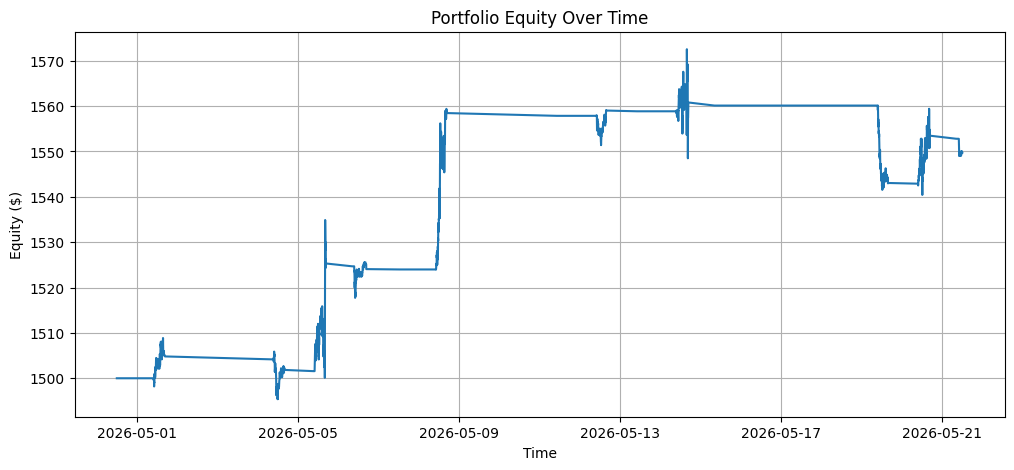

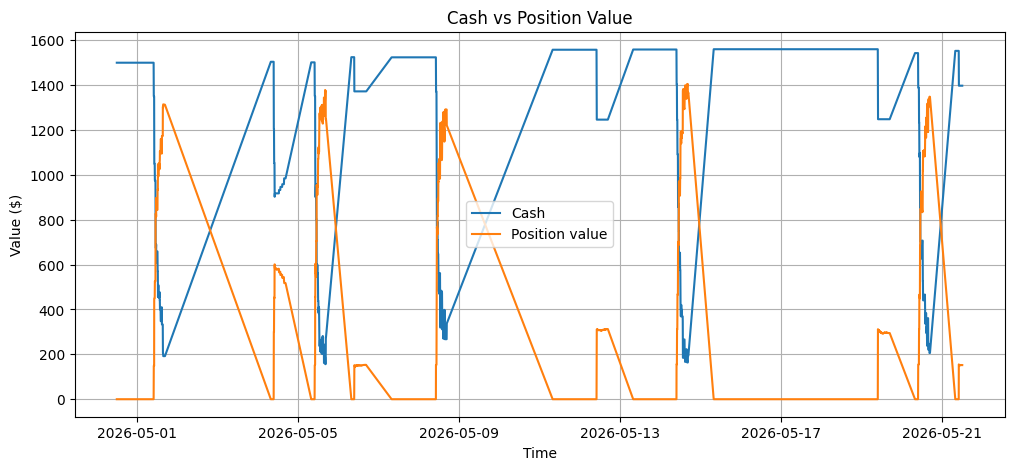

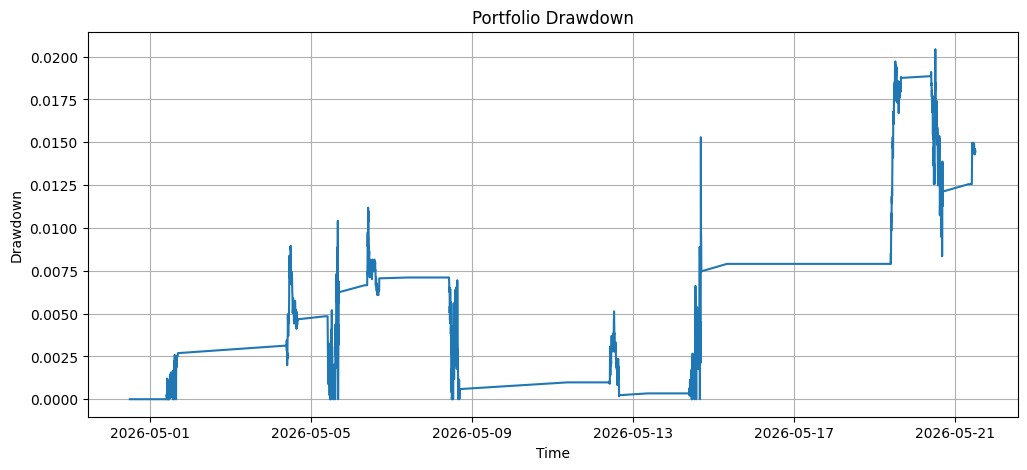

In [2]:
# ============================================================
# ETF-THEME-FIRST DAILY-UNIVERSE BUY / SELL / RISK BACKTEST CELL
# Uses output from the first cell:
#   - raw_bars_df
#   - stationary_tables_by_ticker
#   - TICKERS
#   - daily_selected_by_date
#   - daily_universe_df
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# 1. BACKTEST SETTINGS
# ============================================================

STARTING_CASH = 1500.0

# Buy only uses a fraction of that ticker's daily cash bucket.
# Each selected ticker gets an equal bucket at the start of its trading day.
BUY_FRACTION_OF_BUCKET = 0.50

MIN_TRADE_DOLLARS = 2.00

# Profit sell rule:
# sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER
# Example:
# +1% gain -> 10% sell
# +3% gain -> 30% sell
# +5% gain -> 50% sell
SELL_FRACTION_MULTIPLIER = 10.0

MIN_PROFIT_SELL_FRACTION = 0.10
MAX_PROFIT_SELL_FRACTION = 1.00

# Portfolio-level risk control.
ENABLE_PORTFOLIO_KILL_SWITCH = True
PORTFOLIO_KILL_SWITCH = 0.03   # 3% drawdown from peak equity

# Theme-failure guard.
# The selected ETF/theme chooses the battlefield each day. If that ETF breaks down
# intraday, the bot stops opening NEW buys for the rest of that day.
# Existing positions can still be sold by normal profit-taking, risk, or EOD rules.
ENABLE_THEME_FAILURE_GUARD = True
THEME_FAIL_DROP_FROM_OPEN = 0.005     # 0.5% drop from the theme ETF's regular-session open
THEME_FAIL_USE_BUFFER_LOW = True      # also fail if ETF breaks below its opening-buffer low

# This is recommended for the daily-changing universe.
# It keeps the bot intraday-only and resets buckets each day.
FORCE_CLOSE_EACH_DAY = True

# Trading cost assumptions.
FEE_RATE = 0.0
SLIPPAGE_RATE = 0.0005   # 0.05% assumed slippage


# ============================================================
# 2. SAFETY CHECKS
# ============================================================

required_objects = [
    "raw_bars_df",
    "stationary_tables_by_ticker",
    "TICKERS",
    "daily_selected_by_date",
    "daily_universe_df",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(
            f"Missing {obj_name}. Run the updated stationary-point + daily-universe cell first."
        )

if raw_bars_df.empty:
    raise ValueError("raw_bars_df is empty. Run the Alpaca data cell again.")

if len(stationary_tables_by_ticker) == 0:
    raise ValueError("stationary_tables_by_ticker is empty.")

if daily_universe_df.empty:
    raise ValueError("daily_universe_df is empty. Daily selection produced no stocks.")


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def calculate_profit_sell_fraction(unrealised_return):
    """
    unrealised_return:
        0.03 = +3%
        1.00 = +100%
        -0.02 = -2%

    Profit-taking only happens at confirmed local maximums.
    """

    if unrealised_return <= 0:
        return 0.0

    if unrealised_return >= 1.00:
        return 1.00

    sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER

    sell_fraction = max(sell_fraction, MIN_PROFIT_SELL_FRACTION)
    sell_fraction = min(sell_fraction, MAX_PROFIT_SELL_FRACTION)

    return sell_fraction


def get_current_price(ticker, current_time, bars_by_ticker, last_known_prices):
    """
    Gets current close price for ticker at current_time.
    If exact row is unavailable, use last known price.
    """

    ticker_bars = bars_by_ticker.get(ticker)

    if ticker_bars is None or ticker_bars.empty:
        return last_known_prices.get(ticker, np.nan)

    if current_time in ticker_bars.index:
        price = ticker_bars.loc[current_time, "Close"]

        # If duplicate timestamps somehow occur, take the last one.
        if isinstance(price, pd.Series):
            price = price.iloc[-1]

        last_known_prices[ticker] = price
        return price

    return last_known_prices.get(ticker, np.nan)



def get_selected_theme_by_date(etf_theme_scores_df=None, daily_universe_df=None):
    """
    Returns a dict keyed by date with the ETF/theme selected for that day.

    Expected format:
        {
            date: {
                "theme": "Semiconductors",
                "theme_etf": "SMH",
                "etf_growth_return": 0.25,
            }
        }
    """
    selected_theme_by_date = {}

    if etf_theme_scores_df is not None and not etf_theme_scores_df.empty:
        theme_df = etf_theme_scores_df.copy()

        if "is_selected_theme" in theme_df.columns:
            theme_df = theme_df[theme_df["is_selected_theme"]].copy()

        needed = {"date", "theme", "theme_etf"}
        if needed.issubset(theme_df.columns):
            for _, row in theme_df.iterrows():
                selected_theme_by_date[row["date"]] = {
                    "theme": row.get("theme", "Unknown"),
                    "theme_etf": row.get("theme_etf", None),
                    "etf_growth_return": row.get("etf_growth_return", np.nan),
                }

    # Fallback: use the first selected stock row for each date if the daily universe
    # has theme columns. This keeps the backtest cell usable even if the theme table
    # was not retained in memory for some reason.
    if (not selected_theme_by_date) and daily_universe_df is not None and not daily_universe_df.empty:
        if {"date", "selected_theme", "selected_theme_etf"}.issubset(daily_universe_df.columns):
            for current_date, day_df in daily_universe_df.groupby("date"):
                row = day_df.iloc[0]
                selected_theme_by_date[current_date] = {
                    "theme": row.get("selected_theme", "Unknown"),
                    "theme_etf": row.get("selected_theme_etf", None),
                    "etf_growth_return": row.get("selected_etf_growth", np.nan),
                }

    return selected_theme_by_date


def build_theme_bars_by_etf(raw_bars_df):
    """
    Builds a dict of minute bars for the hard-coded ETF themes from raw_bars_df.
    The first cell downloads these ETFs along with the stock universe.
    """
    if "POPULAR_ETFS_FOR_UNIVERSE" not in globals():
        return {}

    theme_etfs = set(POPULAR_ETFS_FOR_UNIVERSE.values())
    theme_bars_by_etf = {}

    for etf in sorted(theme_etfs):
        etf_df = raw_bars_df[raw_bars_df["ticker"] == etf].copy()
        if etf_df.empty:
            continue

        etf_df = etf_df.set_index("time").sort_index()
        theme_bars_by_etf[etf] = etf_df

    return theme_bars_by_etf


def check_theme_failure(
    current_date,
    current_time,
    selected_theme_by_date,
    theme_bars_by_etf,
    buffer_minutes=15,
    drop_from_open_threshold=0.005,
    use_buffer_low=True,
):
    """
    Theme-failure guard.

    Returns a dict:
        {
            "theme_failed": bool,
            "reason": str,
            "theme": str,
            "theme_etf": str,
            "theme_price": float,
            "theme_open": float,
            "theme_return_from_open": float,
            "theme_buffer_low": float,
        }

    Rule used in this first version:
        After the normal market-open buffer, the selected theme fails if:
            1) ETF is down more than drop_from_open_threshold from its open, OR
            2) ETF breaks below its opening-buffer low.

    This only blocks new buys. It does not force-sell by itself.
    """
    empty_state = {
        "theme_failed": False,
        "reason": "no_theme_failure",
        "theme": None,
        "theme_etf": None,
        "theme_price": np.nan,
        "theme_open": np.nan,
        "theme_return_from_open": np.nan,
        "theme_buffer_low": np.nan,
    }

    theme_info = selected_theme_by_date.get(current_date)
    if not theme_info:
        empty_state["reason"] = "no_selected_theme_for_date"
        return empty_state

    theme = theme_info.get("theme", "Unknown")
    theme_etf = theme_info.get("theme_etf")

    empty_state["theme"] = theme
    empty_state["theme_etf"] = theme_etf

    if not theme_etf or theme_etf not in theme_bars_by_etf:
        empty_state["reason"] = "no_theme_etf_bars"
        return empty_state

    market_open = datetime.combine(current_date, time(9, 30), tzinfo=NY_TZ)
    buffer_end = market_open + timedelta(minutes=buffer_minutes)

    # There are no buys before the buffer anyway, so do not fail the theme before then.
    if current_time < buffer_end:
        empty_state["reason"] = "before_open_buffer_end"
        return empty_state

    theme_bars_today = theme_bars_by_etf[theme_etf]
    theme_bars_today = theme_bars_today[theme_bars_today.index.date == current_date].copy()

    if theme_bars_today.empty:
        empty_state["reason"] = "no_theme_bars_today"
        return empty_state

    bars_so_far = theme_bars_today[theme_bars_today.index <= current_time].copy()
    if bars_so_far.empty:
        empty_state["reason"] = "no_theme_bars_so_far"
        return empty_state

    theme_open = float(theme_bars_today.iloc[0]["Open"])
    theme_price = float(bars_so_far.iloc[-1]["Close"])

    if theme_open <= 0 or not np.isfinite(theme_open) or not np.isfinite(theme_price):
        empty_state["reason"] = "bad_theme_price"
        return empty_state

    theme_return_from_open = (theme_price - theme_open) / theme_open

    buffer_bars = theme_bars_today[
        (theme_bars_today.index >= market_open)
        & (theme_bars_today.index <= buffer_end)
    ]

    theme_buffer_low = np.nan
    broke_buffer_low = False

    if use_buffer_low and not buffer_bars.empty:
        theme_buffer_low = float(buffer_bars["Low"].min())
        broke_buffer_low = theme_price < theme_buffer_low

    failed_by_open_drop = theme_return_from_open <= -drop_from_open_threshold

    failed = failed_by_open_drop or broke_buffer_low

    if failed_by_open_drop and broke_buffer_low:
        reason = "theme_drop_from_open_and_broke_buffer_low"
    elif failed_by_open_drop:
        reason = "theme_drop_from_open"
    elif broke_buffer_low:
        reason = "theme_broke_opening_buffer_low"
    else:
        reason = "no_theme_failure"

    return {
        "theme_failed": bool(failed),
        "reason": reason,
        "theme": theme,
        "theme_etf": theme_etf,
        "theme_price": theme_price,
        "theme_open": theme_open,
        "theme_return_from_open": theme_return_from_open,
        "theme_buffer_low": theme_buffer_low,
    }

def calculate_portfolio_value(cash_pool, stock_cash, positions, bars_by_ticker, current_time, last_known_prices):
    """
    Portfolio equity = unallocated cash pool + daily ticker cash buckets + current position value.
    """

    bucket_cash = sum(stock_cash.values())
    position_value = 0.0

    per_ticker_values = {}

    for ticker in TICKERS:
        price = get_current_price(
            ticker=ticker,
            current_time=current_time,
            bars_by_ticker=bars_by_ticker,
            last_known_prices=last_known_prices
        )

        pos = positions.get(ticker)

        if pos is None:
            ticker_position_value = 0.0
        else:
            ticker_position_value = pos["quantity"] * price if not pd.isna(price) else 0.0

        ticker_total_value = stock_cash.get(ticker, 0.0) + ticker_position_value

        per_ticker_values[ticker] = {
            "cash_bucket": stock_cash.get(ticker, 0.0),
            "position_value": ticker_position_value,
            "total_value": ticker_total_value,
            "price": price
        }

        position_value += ticker_position_value

    total_cash = cash_pool + bucket_cash
    equity = total_cash + position_value

    return equity, total_cash, position_value, per_ticker_values


def close_position(ticker, current_time, reason, cash_pool, stock_cash, positions, bars_by_ticker, last_known_prices, trade_log):
    """
    Closes one ticker position and returns proceeds to that ticker's cash bucket.
    The cash bucket will later be swept back to the global cash pool at end of day.
    """
    pos = positions.get(ticker)

    if pos is None:
        return cash_pool

    current_price = get_current_price(
        ticker=ticker,
        current_time=current_time,
        bars_by_ticker=bars_by_ticker,
        last_known_prices=last_known_prices
    )

    if pd.isna(current_price):
        return cash_pool

    exit_price = current_price * (1 - SLIPPAGE_RATE)

    quantity_to_sell = pos["quantity"]
    gross_value = quantity_to_sell * exit_price
    fee = gross_value * FEE_RATE
    net_value = gross_value - fee

    cost_basis_sold = pos["cost_basis"]
    realised_pnl = net_value - cost_basis_sold

    stock_cash[ticker] = stock_cash.get(ticker, 0.0) + net_value

    trade_log.append({
        "ticker": ticker,
        "action": "SELL",
        "reason": reason,
        "time": current_time,
        "price": exit_price,
        "quantity": quantity_to_sell,
        "gross_value": gross_value,
        "fee": fee,
        "net_value": net_value,
        "cost_basis_sold": cost_basis_sold,
        "realised_pnl": realised_pnl,
        "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
        "stock_cash_after": stock_cash[ticker],
        "cash_pool_after": cash_pool,
    })

    positions[ticker] = None

    return cash_pool


def sweep_buckets_to_cash_pool(cash_pool, stock_cash):
    """
    Moves all ticker bucket cash back into the shared cash pool.
    Used at the end of each trading day.
    """
    cash_pool += sum(stock_cash.values())

    for ticker in stock_cash:
        stock_cash[ticker] = 0.0

    return cash_pool


def allocate_daily_buckets(cash_pool, stock_cash, selected_today):
    """
    Allocates the current cash pool equally across today's selected stocks.

    Important behaviour:
        Every new trading day starts from one shared pool.
        If account equity/cash is $1,700 and 5 stocks are selected,
        every selected stock starts with a $340 bucket, regardless of
        which stock made yesterday's profit.
    """
    for ticker in stock_cash:
        stock_cash[ticker] = 0.0

    selected_today = [ticker for ticker in selected_today if ticker in stock_cash]

    if len(selected_today) == 0 or cash_pool <= 0:
        return cash_pool

    per_ticker_cash = cash_pool / len(selected_today)

    for ticker in selected_today:
        stock_cash[ticker] = per_ticker_cash

    cash_pool = 0.0

    return cash_pool


# ============================================================
# 4. PREPARE BAR DATA
# ============================================================

bars_df = raw_bars_df[raw_bars_df["ticker"].isin(TICKERS)].copy()

required_cols = {"ticker", "time", "Open", "High", "Low", "Close", "Volume"}
missing_cols = required_cols - set(bars_df.columns)

if missing_cols:
    raise ValueError(f"raw_bars_df is missing columns: {missing_cols}")

bars_by_ticker = {}

for ticker in TICKERS:
    ticker_bars = bars_df[bars_df["ticker"] == ticker].copy()

    if ticker_bars.empty:
        print(f"Warning: no bars found for {ticker}")
        continue

    ticker_bars = ticker_bars.set_index("time").sort_index()
    bars_by_ticker[ticker] = ticker_bars

all_times = sorted(bars_df["time"].unique())

if len(all_times) == 0:
    raise ValueError("No timestamps found in bars_df.")

# Date helpers
date_by_time = {t: t.date() for t in all_times}

times_by_date = {}
for t in all_times:
    times_by_date.setdefault(t.date(), []).append(t)

first_time_by_date = {d: min(ts) for d, ts in times_by_date.items()}
last_time_by_date = {d: max(ts) for d, ts in times_by_date.items()}

# Theme-failure guard data. These use the ETF minute bars that were downloaded
# along with the stock universe in the first cell.
selected_theme_by_date = get_selected_theme_by_date(
    etf_theme_scores_df=globals().get("etf_theme_scores_df", pd.DataFrame()),
    daily_universe_df=daily_universe_df,
)
theme_bars_by_etf = build_theme_bars_by_etf(raw_bars_df)

if ENABLE_THEME_FAILURE_GUARD:
    print(f"Theme-failure guard enabled. Loaded ETF bars for: {sorted(theme_bars_by_etf.keys())}")


# ============================================================
# 5. PREPARE SIGNAL EVENTS
# ============================================================

signal_events = []

for ticker, table in stationary_tables_by_ticker.items():
    if table is None or table.empty:
        continue

    temp = table.copy()

    needed_cols = {"ticker", "stationary_type", "confirmation_time", "confirmation_price"}

    missing = needed_cols - set(temp.columns)
    if missing:
        raise ValueError(
            f"Stationary table for {ticker} is missing columns: {missing}"
        )

    for _, row in temp.iterrows():
        stationary_type = row["stationary_type"]

        if stationary_type == "local_minimum":
            signal_action = "buy_check"
        elif stationary_type == "local_maximum":
            signal_action = "profit_sell_check"
        else:
            continue

        confirmation_time = row["confirmation_time"]

        signal_events.append({
            "ticker": ticker,
            "time": confirmation_time,
            "date": confirmation_time.date(),
            "stationary_type": stationary_type,
            "signal_action": signal_action,
            "confirmation_price": row["confirmation_price"],
            "extremum_time": row.get("extremum_time", pd.NaT),
            "extremum_price": row.get("extremum_price", np.nan),
            "validation_status": row.get("validation_status", "")
        })

signals_df = pd.DataFrame(signal_events)

if signals_df.empty:
    print("No signal events found. The backtest will not trade.")
else:
    signals_df = signals_df.sort_values(["time", "ticker"]).reset_index(drop=True)

    # Keep all sell signals because a currently held position may need profit-taking.
    # Filter buy signals so buys only occur:
    #   1) in that day's selected universe
    #   2) after the market-open buffer
    def signal_allowed(row):
        signal_date = row["date"]
        ticker = row["ticker"]

        if row["signal_action"] == "profit_sell_check":
            return True

        selected_today = daily_selected_by_date.get(signal_date, [])

        if ticker not in selected_today:
            return False

        buffer_time = get_market_open_buffer_time(signal_date)

        return row["time"] >= buffer_time

    signals_df["allowed_by_daily_selector"] = signals_df.apply(signal_allowed, axis=1)
    signals_df = signals_df[signals_df["allowed_by_daily_selector"]].copy()

display(signals_df)


# ============================================================
# 6. INITIALISE PORTFOLIO
# ============================================================

cash_pool = STARTING_CASH

stock_cash = {
    ticker: 0.0
    for ticker in TICKERS
}

positions = {
    ticker: None
    for ticker in TICKERS
}

last_known_prices = {}

for ticker in TICKERS:
    if ticker in bars_by_ticker and not bars_by_ticker[ticker].empty:
        first_price = bars_by_ticker[ticker]["Close"].iloc[0]
        last_known_prices[ticker] = first_price

trade_log = []
equity_curve = []
daily_selection_log = []
theme_failure_log = []

peak_equity = STARTING_CASH
trading_stopped = False
kill_switch_time = None

current_day = None
theme_failed_today = False
theme_failure_state_today = None
current_theme_info = {}


# ============================================================
# 7. MAIN BACKTEST LOOP
# ============================================================

for current_time in all_times:

    current_date = current_time.date()

    # ------------------------------------------------------------
    # Start-of-day allocation into today's selected stocks
    # ------------------------------------------------------------

    if current_day != current_date:
        current_day = current_date

        selected_today = daily_selected_by_date.get(current_date, [])

        # Reset daily theme-failure guard. ETF/theme is selected once per day;
        # if it fails, we stop new buys until the next trading day.
        theme_failed_today = False
        theme_failure_state_today = None
        current_theme_info = selected_theme_by_date.get(current_date, {})

        # Defensive reset: before allocating a new day's universe, sweep any leftover
        # cash buckets back into one shared pool. End-of-day close should already do
        # this, but this line makes the equal daily rebalance explicit and robust.
        cash_pool_before_allocation = cash_pool + sum(stock_cash.values())

        if not trading_stopped:
            cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)
            cash_pool = allocate_daily_buckets(
                cash_pool=cash_pool,
                stock_cash=stock_cash,
                selected_today=selected_today
            )

        allocated_buckets = {
            ticker: stock_cash.get(ticker, 0.0)
            for ticker in selected_today
        }

        daily_selection_log.append({
            "date": current_date,
            "selected_tickers": selected_today,
            "selected_theme": current_theme_info.get("theme", None),
            "selected_theme_etf": current_theme_info.get("theme_etf", None),
            "selected_theme_growth": current_theme_info.get("etf_growth_return", np.nan),
            "cash_pool_before_allocation": cash_pool_before_allocation,
            "cash_pool_after_allocation": cash_pool,
            "per_ticker_bucket": (
                cash_pool_before_allocation / len(selected_today)
                if len(selected_today) > 0 and not trading_stopped
                else 0.0
            ),
            "allocated_buckets": allocated_buckets,
        })

    selected_today = daily_selected_by_date.get(current_date, [])

    # ------------------------------------------------------------
    # Update portfolio value at current bar
    # ------------------------------------------------------------

    equity, total_cash, position_value, per_ticker_values = calculate_portfolio_value(
        cash_pool=cash_pool,
        stock_cash=stock_cash,
        positions=positions,
        bars_by_ticker=bars_by_ticker,
        current_time=current_time,
        last_known_prices=last_known_prices
    )

    peak_equity = max(peak_equity, equity)

    drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0.0

    equity_curve.append({
        "time": current_time,
        "equity": equity,
        "cash": total_cash,
        "cash_pool": cash_pool,
        "bucket_cash": sum(stock_cash.values()),
        "position_value": position_value,
        "drawdown": drawdown,
        "open_positions": sum(pos is not None for pos in positions.values()),
        "selected_count": len(selected_today),
        "selected_theme": current_theme_info.get("theme", None),
        "selected_theme_etf": current_theme_info.get("theme_etf", None),
        "theme_failed_today": theme_failed_today,
    })

    # ------------------------------------------------------------
    # Portfolio-level risk control
    # ------------------------------------------------------------

    if (
        ENABLE_PORTFOLIO_KILL_SWITCH
        and not trading_stopped
        and drawdown >= PORTFOLIO_KILL_SWITCH
    ):
        trading_stopped = True
        kill_switch_time = current_time

        print(f"Portfolio kill switch triggered at {current_time}. Drawdown = {drawdown:.2%}")

        for ticker in TICKERS:
            cash_pool = close_position(
                ticker=ticker,
                current_time=current_time,
                reason="portfolio_kill_switch",
                cash_pool=cash_pool,
                stock_cash=stock_cash,
                positions=positions,
                bars_by_ticker=bars_by_ticker,
                last_known_prices=last_known_prices,
                trade_log=trade_log
            )

        cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)

        continue

    # ------------------------------------------------------------
    # Theme-failure guard
    # ------------------------------------------------------------
    # If the ETF/theme selected for the day starts breaking down, stop new buys
    # for the rest of the day. Sells are still allowed. No intraday ETF switching.

    if (
        ENABLE_THEME_FAILURE_GUARD
        and not trading_stopped
        and not theme_failed_today
    ):
        theme_state = check_theme_failure(
            current_date=current_date,
            current_time=current_time,
            selected_theme_by_date=selected_theme_by_date,
            theme_bars_by_etf=theme_bars_by_etf,
            buffer_minutes=MARKET_OPEN_BUFFER_MINUTES,
            drop_from_open_threshold=THEME_FAIL_DROP_FROM_OPEN,
            use_buffer_low=THEME_FAIL_USE_BUFFER_LOW,
        )

        if theme_state.get("theme_failed", False):
            theme_failed_today = True
            theme_failure_state_today = theme_state

            theme_failure_log.append({
                "date": current_date,
                "time": current_time,
                **theme_state,
            })

            print(
                f"Theme-failure guard triggered at {current_time}: "
                f"{theme_state.get('theme')} ({theme_state.get('theme_etf')}) | "
                f"reason={theme_state.get('reason')} | "
                f"return_from_open={theme_state.get('theme_return_from_open', np.nan):.2%}"
            )

    if not trading_stopped:

        # ------------------------------------------------------------
        # Process signals that occur at this timestamp
        # ------------------------------------------------------------

        if not signals_df.empty:
            current_signals = signals_df[signals_df["time"] == current_time]
        else:
            current_signals = pd.DataFrame()

        if not current_signals.empty:
            # Process sell checks before buy checks at the same timestamp.
            action_order = {
                "profit_sell_check": 0,
                "buy_check": 1
            }

            current_signals = current_signals.copy()
            current_signals["action_order"] = current_signals["signal_action"].map(action_order)
            current_signals = current_signals.sort_values(["action_order", "ticker"])

            for _, signal in current_signals.iterrows():
                ticker = signal["ticker"]
                signal_action = signal["signal_action"]

                current_price = get_current_price(
                    ticker=ticker,
                    current_time=current_time,
                    bars_by_ticker=bars_by_ticker,
                    last_known_prices=last_known_prices
                )

                if pd.isna(current_price):
                    continue

                # ========================================================
                # SELL LOGIC
                # ========================================================

                if signal_action == "profit_sell_check":
                    pos = positions[ticker]

                    if pos is None:
                        continue

                    market_value = pos["quantity"] * current_price
                    unrealised_pnl = market_value - pos["cost_basis"]
                    unrealised_return = unrealised_pnl / pos["cost_basis"] if pos["cost_basis"] > 0 else 0.0

                    sell_fraction = calculate_profit_sell_fraction(unrealised_return)

                    if sell_fraction <= 0:
                        trade_log.append({
                            "ticker": ticker,
                            "action": "NO_SELL",
                            "reason": "local_maximum_but_not_profitable",
                            "time": current_time,
                            "price": current_price,
                            "quantity": 0.0,
                            "gross_value": 0.0,
                            "fee": 0.0,
                            "net_value": 0.0,
                            "cost_basis_sold": 0.0,
                            "realised_pnl": 0.0,
                            "realised_return_pct": 0.0,
                            "unrealised_return_pct": unrealised_return,
                            "stock_cash_after": stock_cash[ticker],
                            "cash_pool_after": cash_pool,
                        })
                        continue

                    quantity_to_sell = pos["quantity"] * sell_fraction

                    exit_price = current_price * (1 - SLIPPAGE_RATE)
                    gross_value = quantity_to_sell * exit_price
                    fee = gross_value * FEE_RATE
                    net_value = gross_value - fee

                    cost_basis_sold = pos["cost_basis"] * sell_fraction
                    realised_pnl = net_value - cost_basis_sold

                    stock_cash[ticker] += net_value

                    pos["quantity"] -= quantity_to_sell
                    pos["cost_basis"] -= cost_basis_sold

                    if pos["quantity"] <= 1e-10 or sell_fraction >= 1.0:
                        positions[ticker] = None
                    else:
                        positions[ticker] = pos

                    trade_log.append({
                        "ticker": ticker,
                        "action": "SELL",
                        "reason": "confirmed_maximum_profit_take",
                        "time": current_time,
                        "price": exit_price,
                        "quantity": quantity_to_sell,
                        "gross_value": gross_value,
                        "fee": fee,
                        "net_value": net_value,
                        "cost_basis_sold": cost_basis_sold,
                        "realised_pnl": realised_pnl,
                        "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
                        "unrealised_return_pct_before_sell": unrealised_return,
                        "sell_fraction": sell_fraction,
                        "stock_cash_after": stock_cash[ticker],
                        "cash_pool_after": cash_pool,
                    })

                # ========================================================
                # BUY LOGIC
                # ========================================================
                # Buy/reinvest only happens at confirmed local minimums.
                # The ticker must be in today's selected universe and past the buffer.
                # Uses only that ticker's own daily cash bucket.
                # ========================================================

                elif signal_action == "buy_check":

                    if ticker not in selected_today:
                        continue

                    buffer_time = get_market_open_buffer_time(current_date)

                    if current_time < buffer_time:
                        continue

                    if theme_failed_today:
                        trade_log.append({
                            "ticker": ticker,
                            "action": "NO_BUY",
                            "reason": "theme_failure_guard",
                            "time": current_time,
                            "price": current_price,
                            "quantity": 0.0,
                            "gross_value": 0.0,
                            "fee": 0.0,
                            "net_value": 0.0,
                            "selected_theme": current_theme_info.get("theme", None),
                            "selected_theme_etf": current_theme_info.get("theme_etf", None),
                            "theme_failure_reason": (theme_failure_state_today or {}).get("reason", None),
                            "stock_cash_after": stock_cash[ticker],
                            "cash_pool_after": cash_pool,
                        })
                        continue

                    available_cash = stock_cash[ticker]

                    if available_cash < MIN_TRADE_DOLLARS:
                        trade_log.append({
                            "ticker": ticker,
                            "action": "NO_BUY",
                            "reason": "not_enough_ticker_cash",
                            "time": current_time,
                            "price": current_price,
                            "quantity": 0.0,
                            "gross_value": 0.0,
                            "fee": 0.0,
                            "net_value": 0.0,
                            "stock_cash_after": stock_cash[ticker],
                            "cash_pool_after": cash_pool,
                        })
                        continue

                    amount_to_spend = available_cash * BUY_FRACTION_OF_BUCKET

                    if amount_to_spend < MIN_TRADE_DOLLARS:
                        trade_log.append({
                            "ticker": ticker,
                            "action": "NO_BUY",
                            "reason": "trade_too_small",
                            "time": current_time,
                            "price": current_price,
                            "quantity": 0.0,
                            "gross_value": 0.0,
                            "fee": 0.0,
                            "net_value": 0.0,
                            "stock_cash_after": stock_cash[ticker],
                            "cash_pool_after": cash_pool,
                        })
                        continue

                    entry_price = current_price * (1 + SLIPPAGE_RATE)

                    quantity_to_buy = amount_to_spend / entry_price
                    gross_cost = quantity_to_buy * entry_price
                    fee = gross_cost * FEE_RATE
                    total_cost = gross_cost + fee

                    if total_cost > stock_cash[ticker]:
                        total_cost = stock_cash[ticker]
                        gross_cost = total_cost / (1 + FEE_RATE)
                        fee = total_cost - gross_cost
                        quantity_to_buy = gross_cost / entry_price

                    stock_cash[ticker] -= total_cost

                    existing_pos = positions[ticker]

                    if existing_pos is None:
                        positions[ticker] = {
                            "quantity": quantity_to_buy,
                            "cost_basis": total_cost,
                            "avg_entry_price": total_cost / quantity_to_buy,
                            "first_entry_time": current_time,
                            "last_entry_time": current_time
                        }
                    else:
                        new_quantity = existing_pos["quantity"] + quantity_to_buy
                        new_cost_basis = existing_pos["cost_basis"] + total_cost

                        existing_pos["quantity"] = new_quantity
                        existing_pos["cost_basis"] = new_cost_basis
                        existing_pos["avg_entry_price"] = new_cost_basis / new_quantity
                        existing_pos["last_entry_time"] = current_time

                        positions[ticker] = existing_pos

                    trade_log.append({
                        "ticker": ticker,
                        "action": "BUY",
                        "reason": "confirmed_minimum_buy_or_reinvest",
                        "time": current_time,
                        "price": entry_price,
                        "quantity": quantity_to_buy,
                        "gross_value": gross_cost,
                        "fee": fee,
                        "net_value": total_cost,
                        "stock_cash_after": stock_cash[ticker],
                        "cash_pool_after": cash_pool,
                    })

    # ------------------------------------------------------------
    # End-of-day forced close and bucket reset
    # ------------------------------------------------------------

    if FORCE_CLOSE_EACH_DAY and current_time == last_time_by_date[current_date]:

        for ticker in TICKERS:
            cash_pool = close_position(
                ticker=ticker,
                current_time=current_time,
                reason="forced_end_of_day_close",
                cash_pool=cash_pool,
                stock_cash=stock_cash,
                positions=positions,
                bars_by_ticker=bars_by_ticker,
                last_known_prices=last_known_prices,
                trade_log=trade_log
            )

        cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)


# ============================================================
# 8. FINAL VALUATION
# ============================================================

final_time = all_times[-1]

final_equity, final_cash, final_position_value, final_per_ticker_values = calculate_portfolio_value(
    cash_pool=cash_pool,
    stock_cash=stock_cash,
    positions=positions,
    bars_by_ticker=bars_by_ticker,
    current_time=final_time,
    last_known_prices=last_known_prices
)

equity_df = pd.DataFrame(equity_curve)
trades_df = pd.DataFrame(trade_log)
daily_selection_log_df = pd.DataFrame(daily_selection_log)
theme_failure_log_df = pd.DataFrame(theme_failure_log)

print("\nDaily allocation check: each selected ticker should receive the same bucket each morning.")
if not daily_selection_log_df.empty:
    alloc_display_cols = [
        "date", "selected_theme", "selected_theme_etf", "selected_theme_growth",
        "selected_tickers", "cash_pool_before_allocation",
        "per_ticker_bucket", "allocated_buckets"
    ]
    alloc_display_cols = [c for c in alloc_display_cols if c in daily_selection_log_df.columns]
    display(daily_selection_log_df[alloc_display_cols])

open_positions_summary = []

for ticker in TICKERS:
    pos = positions[ticker]

    current_price = get_current_price(
        ticker=ticker,
        current_time=final_time,
        bars_by_ticker=bars_by_ticker,
        last_known_prices=last_known_prices
    )

    if pos is None:
        open_positions_summary.append({
            "ticker": ticker,
            "cash_bucket": stock_cash[ticker],
            "quantity": 0.0,
            "avg_entry_price": np.nan,
            "final_price": current_price,
            "position_value": 0.0,
            "cost_basis": 0.0,
            "unrealised_pnl": 0.0,
            "unrealised_return_pct": 0.0,
            "total_ticker_value": stock_cash[ticker]
        })
    else:
        position_value = pos["quantity"] * current_price
        unrealised_pnl = position_value - pos["cost_basis"]
        unrealised_return = unrealised_pnl / pos["cost_basis"] if pos["cost_basis"] > 0 else np.nan

        open_positions_summary.append({
            "ticker": ticker,
            "cash_bucket": stock_cash[ticker],
            "quantity": pos["quantity"],
            "avg_entry_price": pos["avg_entry_price"],
            "final_price": current_price,
            "position_value": position_value,
            "cost_basis": pos["cost_basis"],
            "unrealised_pnl": unrealised_pnl,
            "unrealised_return_pct": unrealised_return,
            "total_ticker_value": stock_cash[ticker] + position_value
        })

open_positions_df = pd.DataFrame(open_positions_summary)


# ============================================================
# 9. RESULTS
# ============================================================

total_profit = final_equity - STARTING_CASH
total_return = total_profit / STARTING_CASH

print("=" * 100)
print("DAILY-UNIVERSE STATIONARY-POINT BACKTEST RESULTS")
print("=" * 100)
print(f"Starting cash:          ${STARTING_CASH:,.2f}")
print(f"Final equity:           ${final_equity:,.2f}")
print(f"Final cash:             ${final_cash:,.2f}")
print(f"Final position value:   ${final_position_value:,.2f}")
print(f"Total profit:           ${total_profit:,.2f}")
print(f"Total return:           {total_return:.2%}")

if not equity_df.empty:
    max_drawdown = equity_df["drawdown"].max()
    print(f"Max drawdown:           {max_drawdown:.2%}")

if kill_switch_time is not None:
    print(f"Kill switch triggered:  {kill_switch_time}")
else:
    print("Kill switch triggered:  No")

print("\n")

if trades_df.empty:
    print("No trades were made.")
else:
    buy_count = len(trades_df[trades_df["action"] == "BUY"])
    sell_count = len(trades_df[trades_df["action"] == "SELL"])

    realised_sells = trades_df[
        (trades_df["action"] == "SELL")
        & (trades_df["realised_pnl"].notna())
    ].copy() if "realised_pnl" in trades_df.columns else pd.DataFrame()

    print(f"Buy trades:             {buy_count}")
    print(f"Sell trades:            {sell_count}")

    if not realised_sells.empty:
        winning_sells = realised_sells[realised_sells["realised_pnl"] > 0]
        losing_sells = realised_sells[realised_sells["realised_pnl"] < 0]

        win_rate = len(winning_sells) / len(realised_sells)

        print(f"Realised sell trades:   {len(realised_sells)}")
        print(f"Win rate:               {win_rate:.2%}")
        print(f"Realised PnL:           ${realised_sells['realised_pnl'].sum():,.2f}")
        print(f"Average sell PnL:       ${realised_sells['realised_pnl'].mean():,.2f}")
        print(f"Best sell PnL:          ${realised_sells['realised_pnl'].max():,.2f}")
        print(f"Worst sell PnL:         ${realised_sells['realised_pnl'].min():,.2f}")

print("\n")


# ============================================================
# 10. DISPLAY TABLES
# ============================================================

print("=" * 100)
print("DAILY SELECTED UNIVERSE")
print("=" * 100)
daily_display_cols = [
    "date", "ticker", "sector", "final_score",
    "historical_suitability_score", "daily_strength_score",
    "tradable_volatility_score", "market_sector_confirmation_score",
    "open_momentum", "relative_strength_vs_spy", "relative_strength_vs_sector",
    "ATR_percent_daily", "gap_pct", "gap_vs_atr", "prev_dollar_volume"
]
daily_display_cols = [c for c in daily_display_cols if c in daily_universe_df.columns]
display(daily_universe_df[daily_display_cols].round(6))

print("=" * 100)
print("DAILY ALLOCATION LOG")
print("=" * 100)
display(daily_selection_log_df)

print("=" * 100)
print("THEME FAILURE LOG")
print("=" * 100)
if theme_failure_log_df.empty:
    print("No theme-failure guard triggers.")
else:
    display(theme_failure_log_df)

print("=" * 100)
print("OPEN POSITIONS / FINAL TICKER VALUES")
print("=" * 100)
display(open_positions_df.sort_values("total_ticker_value", ascending=False))

print("=" * 100)
print("TRADES")
print("=" * 100)
if trades_df.empty:
    print("No trades.")
else:
    display(trades_df)


# ============================================================
# 11. PLOTS
# ============================================================

if not equity_df.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(equity_df["time"], equity_df["equity"])
    plt.title("Portfolio Equity Over Time")
    plt.xlabel("Time")
    plt.ylabel("Equity ($)")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(equity_df["time"], equity_df["cash"], label="Cash")
    plt.plot(equity_df["time"], equity_df["position_value"], label="Position value")
    plt.title("Cash vs Position Value")
    plt.xlabel("Time")
    plt.ylabel("Value ($)")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(equity_df["time"], equity_df["drawdown"])
    plt.title("Portfolio Drawdown")
    plt.xlabel("Time")
    plt.ylabel("Drawdown")
    plt.grid(True)
    plt.show()
